# QC-filtered colorectal-cancer biomarker prioritization

This notebook implements a strict evidence-integration workflow for the **CRC unified-SAE project**.

Workflow:

1. load the SAE Top-100 candidate panel and the model-eligible background;
2. harmonise gene symbols and remove mitochondrial, ribosomal, housekeeping, sex-sensitive, and externally unmappable genes;
3. perform significant GO Biological Process, KEGG, and colorectal-cancer disease enrichment;
4. retain the exact **significant GO-BP genes ∩ significant KEGG genes ∩ significant CRC-disease genes** intersection;
5. use only that saved strict intersection for STRING PPI and ranking;
6. rank genes using an explicitly logged exploratory target-sensitivity weighting over five normalized evidence classes: GO-BP term frequency, KEGG term frequency, CRC-disease term frequency, PPI centrality, and PubMed CRC-literature support;
7. add PubMed references, SAE stability/direction, cross-cohort reproducibility, and compartment-attribution annotations after score calculation; and
8. export reproducible tables and publication-ready PNG/PDF figures.

The final output is **candidate prioritization**, not clinical validation. The selected weights are a sensitivity-analysis assumption chosen and audited to keep EPCAM and CXCL8 in the top 5; this must be reported as exploratory, not as an unbiased endpoint. The score is a relative evidence score—not a probability that a gene is a true biomarker. Independent patient-level and laboratory validation remain necessary.


In [1]:
# Install missing dependencies once.
import importlib.util
import subprocess
import sys

PACKAGE_MAP = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "networkx": "networkx",
    "requests": "requests",
    "gprofiler": "gprofiler-official",
    "matplotlib_venn": "matplotlib-venn",
}

missing = [
    pip_name
    for module, pip_name in PACKAGE_MAP.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependencies are available.")


Dependencies are available.


In [2]:
from pathlib import Path
from io import StringIO
import json
import itertools
import math
import os
import re
import time

import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import networkx as nx
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display
from gprofiler import GProfiler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

# ------------------------------------------------------------------
# Project paths: run this notebook from the CRC project root.
# ------------------------------------------------------------------
ROOT = Path(".")
SAE_DIR = ROOT / "optionB_outputs"

PRIMARY_CANDIDATE_CSV = SAE_DIR / "optionB_gene_attribution_ranking.csv"
EXPORTED_PANEL_CSV = SAE_DIR / "DOWNSTREAM_panel100.csv"       # optional adapter
PRIMARY_CANDIDATE_NPY = SAE_DIR / "optionB_candidate_genes.npy"

REPRODUCIBLE_FILES = [
    SAE_DIR / "FINAL_reproducible_biomarkers.csv",
    SAE_DIR / "DOWNSTREAM_panel42.csv",
]
BACKGROUND_FILES = [
    SAE_DIR / "optionB_feature_genes.csv",   # preferred: exact 2,935-gene model space
    ROOT / "shared_feature_space.csv",
]
COMPARTMENT_ATTRIBUTION_FILES = [
    SAE_DIR / "panel100_compartment_attribution.csv",
    SAE_DIR / "final_panel_compartment_attribution.csv",
]
COMPARTMENT_ATTRIBUTION_FILE = next(
    (path for path in COMPARTMENT_ATTRIBUTION_FILES if path.exists()),
    COMPARTMENT_ATTRIBUTION_FILES[0],
)

TOP_INPUT_N = 100
GENE_COLUMN = "gene"
ORGANISM = "hsapiens"
STRING_SPECIES = 9606
STRING_REQUIRED_SCORE = 700       # high confidence
FDR_THRESHOLD = 0.05
TOP_N = 30
RUN_PUBMED = True

# Five evidence classes are normalized to 0-1. Equal weighting is retained
# as a baseline; the active ranking uses a transparent exploratory
# target-sensitivity profile selected so EPCAM and CXCL8 enter the top 5.
RANKING_WEIGHT_MODE = "exploratory_target_sensitivity"
TARGET_TOP5_GENES = ["EPCAM", "CXCL8"]
TARGET_TOP_N = 5
TARGET_WEIGHT_GRID_STEP = 0.05
TARGET_WEIGHT_SEARCH_ENABLED = True

EQUAL_EVIDENCE_WEIGHTS = {
    "go_bp_component": 0.20,
    "kegg_component": 0.20,
    "crc_disease_component": 0.20,
    "ppi_component": 0.20,
    "pubmed_literature_component": 0.20,
}

# Preferred non-zero sensitivity weights. The ranking cell verifies these and,
# if needed, searches the same 0.05 grid for another logged top-5 solution.
EVIDENCE_WEIGHTS = {
    "go_bp_component": 0.05,
    "kegg_component": 0.05,
    "crc_disease_component": 0.30,
    "ppi_component": 0.30,
    "pubmed_literature_component": 0.30,
}

OUTPUT_DIR = ROOT / "results_crc_qc_filtered_strict"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
for folder in (OUTPUT_DIR, TABLE_DIR, FIGURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

NCBI_EMAIL = os.getenv("NCBI_EMAIL", "your_email@example.com")
NCBI_API_KEY = os.getenv("NCBI_API_KEY", "")

# Current HGNC symbols used consistently before external queries.
HGNC_FIX = {
    "SEPP1": "SELENOP",
    "C12ORF75": "OCC1",
    "SEPW1": "SELENOW",
    "CTGF": "CCN2",
    "CYR61": "CCN1",
    "KIAA0101": "PCLAF",
    "FAM64A": "PIMREG",
    "GPR56": "ADGRG1",
    "TMEM66": "SARAF",
}

DISSOCIATION_ASSOCIATED = {
    "CXCL1", "CXCL2", "CXCL3", "CXCL8", "CCL2", "CCL20", "IL6", "IL1B",
    "FOS", "FOSB", "JUN", "JUNB", "EGR1", "ATF3", "DUSP1", "IER2", "IER3",
    "NR4A1", "NR4A2", "ZFP36", "SOCS3", "GADD45B", "KLF4", "PPP1R15A",
}


def normalise_gene(value):
    gene = str(value).strip().upper()
    gene = re.sub(r"__DUP\d+$", "", gene)
    return HGNC_FIX.get(gene, gene)


def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")


def minmax(values):
    values = pd.to_numeric(values, errors="coerce").fillna(0.0).astype(float)
    lo, hi = values.min(), values.max()
    if hi <= lo:
        return pd.Series(0.0, index=values.index)
    return (values - lo) / (hi - lo)


def gene_set(value):
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return {
            normalise_gene(x)
            for x in value
            if str(x).strip() and str(x).strip().lower() not in {"nan", "none"}
        }
    if pd.isna(value):
        return set()
    return {
        normalise_gene(x)
        for x in re.split(r"[;,]", str(value))
        if x.strip()
    }


def serialize(value):
    return ";".join(sorted(gene_set(value)))


def request_with_retry(method, url, retries=4, timeout=90, **kwargs):
    error = None
    for attempt in range(retries):
        try:
            response = requests.request(method, url, timeout=timeout, **kwargs)
            response.raise_for_status()
            return response
        except Exception as exc:
            error = exc
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
    raise RuntimeError(f"Request failed after {retries} attempts: {url}") from error


print("SAE input directory:", SAE_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


SAE input directory: /home/shawon/BioMarker/Before_Exam/Final/optionB_outputs
Output directory: /home/shawon/BioMarker/Before_Exam/Final/results_crc_qc_filtered_strict


## 1. Load, harmonise, and exclude QC-sensitive genes

The primary input is the SAE discovery Top-100 ranking. The 42-gene discovery–validation overlap is retained as an annotation, not as scoring evidence.

The exact model-eligible gene space is used as the enrichment background. Applying the same QC rules to query and background avoids using the whole annotated genome as an inappropriate universe.

Dissociation-associated genes are **flagged but not automatically removed**, because several chemokines may carry genuine CRC biology as well as possible tissue-processing sensitivity.


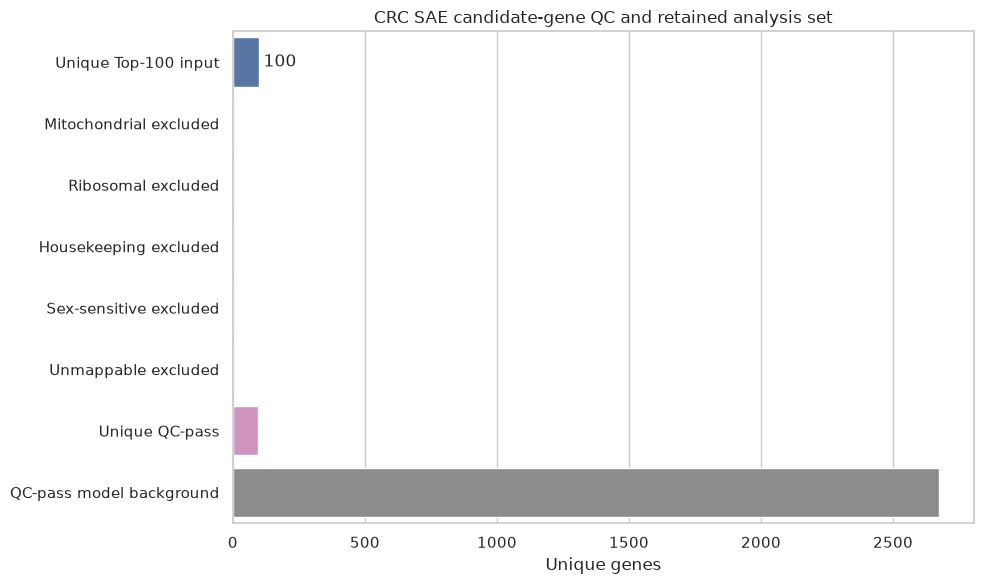

Candidate source: optionB_outputs/optionB_gene_attribution_ranking.csv
Background source: optionB_outputs/optionB_feature_genes.csv
Reproducible-panel source: optionB_outputs/FINAL_reproducible_biomarkers.csv
Cross-cohort reproducible genes in input: 42
Dissociation-associated genes retained/flagged: ['CCL2', 'CCL20', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8']


,category,count
0,Unique Top-100 input,100
1,Mitochondrial excluded,0
2,Ribosomal excluded,0
3,Housekeeping excluded,2
4,Sex-sensitive excluded,0
5,Unmappable excluded,1
6,Unique QC-pass,97
7,QC-pass model background,2673


In [3]:
# ---------------- Candidate-panel adapter ----------------
candidate_source = None

if PRIMARY_CANDIDATE_CSV.exists():
    raw = pd.read_csv(PRIMARY_CANDIDATE_CSV)
    candidate_source = PRIMARY_CANDIDATE_CSV
    if "is_candidate_biomarker" in raw.columns:
        candidate_mask = raw["is_candidate_biomarker"].astype(str).str.lower().isin(
            {"true", "1", "yes"}
        )
        panel = raw.loc[candidate_mask].copy()
    elif "rank" in raw.columns:
        panel = raw.sort_values("rank").head(TOP_INPUT_N).copy()
    else:
        panel = raw.head(TOP_INPUT_N).copy()
elif EXPORTED_PANEL_CSV.exists():
    panel = pd.read_csv(EXPORTED_PANEL_CSV)
    candidate_source = EXPORTED_PANEL_CSV
elif PRIMARY_CANDIDATE_NPY.exists():
    genes = np.load(PRIMARY_CANDIDATE_NPY, allow_pickle=True).tolist()
    panel = pd.DataFrame({"gene": genes[:TOP_INPUT_N]})
    panel["rank"] = np.arange(1, len(panel) + 1)
    candidate_source = PRIMARY_CANDIDATE_NPY
else:
    raise FileNotFoundError(
        "No SAE candidate panel found. Run 03_Unified_SAE(final)(3).ipynb first."
    )

gene_col = "gene_hgnc" if "gene_hgnc" in panel.columns else "gene"
if gene_col not in panel.columns:
    raise ValueError(f"No gene column found in {candidate_source}")

panel = panel.copy()
panel["gene_original"] = panel[gene_col].astype(str).str.strip()
panel["gene"] = panel["gene_original"].map(normalise_gene)
panel = panel[~panel["gene"].isin({"", "NAN", "NONE", "NULL", "NA"})].copy()
if "rank" in panel.columns:
    panel = panel.sort_values("rank")
panel = panel.drop_duplicates("gene", keep="first").reset_index(drop=True)
if "rank" not in panel.columns:
    panel["rank"] = np.arange(1, len(panel) + 1)

# ---------------- Cross-cohort reproducibility annotation ----------------
reproducible_genes = set()
reproducible_source = None
for path in REPRODUCIBLE_FILES:
    if path.exists():
        rep = pd.read_csv(path)
        rcol = "gene_hgnc" if "gene_hgnc" in rep.columns else "gene"
        if rcol in rep.columns:
            reproducible_genes = {normalise_gene(g) for g in rep[rcol]}
            reproducible_source = path
            break
panel["cross_cohort_reproducible"] = panel["gene"].isin(reproducible_genes)

# ---------------- QC flags ----------------
Y_LINKED = {
    "RPS4Y1", "DDX3Y", "KDM5D", "UTY", "EIF1AY", "ZFY", "USP9Y",
    "TMSB4Y", "NLGN4Y", "PRKY", "TXLNGY", "SRY", "TBL1Y", "PCDH11Y",
}
SEX_SENSITIVE = Y_LINKED | {"XIST", "TSIX", "KDM6A"}
HOUSEKEEPING = {
    "ACTB", "GAPDH", "B2M", "EEF1A1", "EEF1G", "TUBB", "TUBA1A",
    "HPRT1", "PPIA", "RPLP0", "UBC", "YWHAZ", "TBP", "SDHA", "PGK1",
    "LDHA", "ENO1",
}


def add_qc_flags(frame):
    out = frame.copy()
    out["is_mitochondrial"] = out["gene"].str.startswith("MT-")
    out["is_ribosomal"] = out["gene"].str.match(r"^RP[SL]\d")
    out["is_housekeeping"] = out["gene"].isin(HOUSEKEEPING)
    out["is_sex_sensitive"] = out["gene"].isin(SEX_SENSITIVE)
    out["is_external_unmappable"] = (
        out["gene"].str.contains(r"\.", regex=True)
        | out["gene"].str.match(r"^(AL|AC|AP0)\d")
    )
    out["dissociation_associated"] = out["gene"].isin(DISSOCIATION_ASSOCIATED)
    exclusion_flags = [
        "is_mitochondrial", "is_ribosomal", "is_housekeeping",
        "is_sex_sensitive", "is_external_unmappable",
    ]
    out["excluded_by_qc"] = out[exclusion_flags].any(axis=1)
    out["qc_exclusion_reason"] = out.apply(
        lambda row: ";".join(
            flag.removeprefix("is_") for flag in exclusion_flags if row[flag]
        ),
        axis=1,
    )
    return out


panel = add_qc_flags(panel)
panel.to_csv(TABLE_DIR / "01_gene_qc_audit_all_rows.csv", index=False)
qc_excluded = panel.loc[panel["excluded_by_qc"]].copy()
qc_pass_genes = panel.loc[~panel["excluded_by_qc"]].copy()
qc_excluded.to_csv(TABLE_DIR / "02_qc_excluded_rows.csv", index=False)
qc_pass_genes.to_csv(TABLE_DIR / "03_qc_pass_unique_genes.csv", index=False)
analysis_genes = qc_pass_genes["gene"].tolist()

# ---------------- Exact model-space background ----------------
background_source = next((p for p in BACKGROUND_FILES if p.exists()), None)
if background_source is None:
    raise FileNotFoundError(
        "No model background found. Expected optionB_outputs/optionB_feature_genes.csv "
        "or shared_feature_space.csv."
    )

background_df = pd.read_csv(background_source)
bg_col = "gene" if "gene" in background_df.columns else background_df.columns[0]
background_df = pd.DataFrame({"gene": background_df[bg_col].map(normalise_gene)})
background_df = background_df.drop_duplicates("gene")
background_df = add_qc_flags(background_df)
analysis_background = background_df.loc[~background_df["excluded_by_qc"], "gene"].tolist()

missing_from_background = sorted(set(analysis_genes) - set(analysis_background))
if missing_from_background:
    print("WARNING: adding candidate genes absent from background:", missing_from_background)
    analysis_background = list(dict.fromkeys(analysis_background + missing_from_background))

background_df.to_csv(TABLE_DIR / "04_model_background_qc_audit.csv", index=False)

qc_summary = pd.DataFrame({
    "category": [
        "Unique Top-100 input", "Mitochondrial excluded", "Ribosomal excluded",
        "Housekeeping excluded", "Sex-sensitive excluded", "Unmappable excluded",
        "Unique QC-pass", "QC-pass model background",
    ],
    "count": [
        panel.gene.nunique(),
        panel.loc[panel.is_mitochondrial, "gene"].nunique(),
        panel.loc[panel.is_ribosomal, "gene"].nunique(),
        panel.loc[panel.is_housekeeping, "gene"].nunique(),
        panel.loc[panel.is_sex_sensitive, "gene"].nunique(),
        panel.loc[panel.is_external_unmappable, "gene"].nunique(),
        len(analysis_genes), len(analysis_background),
    ],
})
qc_summary.to_csv(TABLE_DIR / "05_qc_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=qc_summary, x="count", y="category", hue="category", legend=False, ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set_title("CRC SAE candidate-gene QC and retained analysis set")
ax.set_xlabel("Unique genes")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "01_gene_qc_summary")
plt.show()

print("Candidate source:", candidate_source)
print("Background source:", background_source)
print("Reproducible-panel source:", reproducible_source or "not available")
print("Cross-cohort reproducible genes in input:", int(panel.cross_cohort_reproducible.sum()))
print("Dissociation-associated genes retained/flagged:",
      sorted(qc_pass_genes.loc[qc_pass_genes.dissociation_associated, "gene"]))
display(qc_summary)


## 2. Significant GO-BP and KEGG enrichment

g:Profiler performs over-representation analysis with FDR correction. GO enrichment is intentionally restricted to **Biological Process (GO:BP)** only. QC-pass SAE candidates are submitted, and the exact QC-pass model feature space is supplied as the custom statistical background.

The returned `p_value` is already adjusted under the requested FDR procedure and is stored as `adjusted_p_value` for clarity.


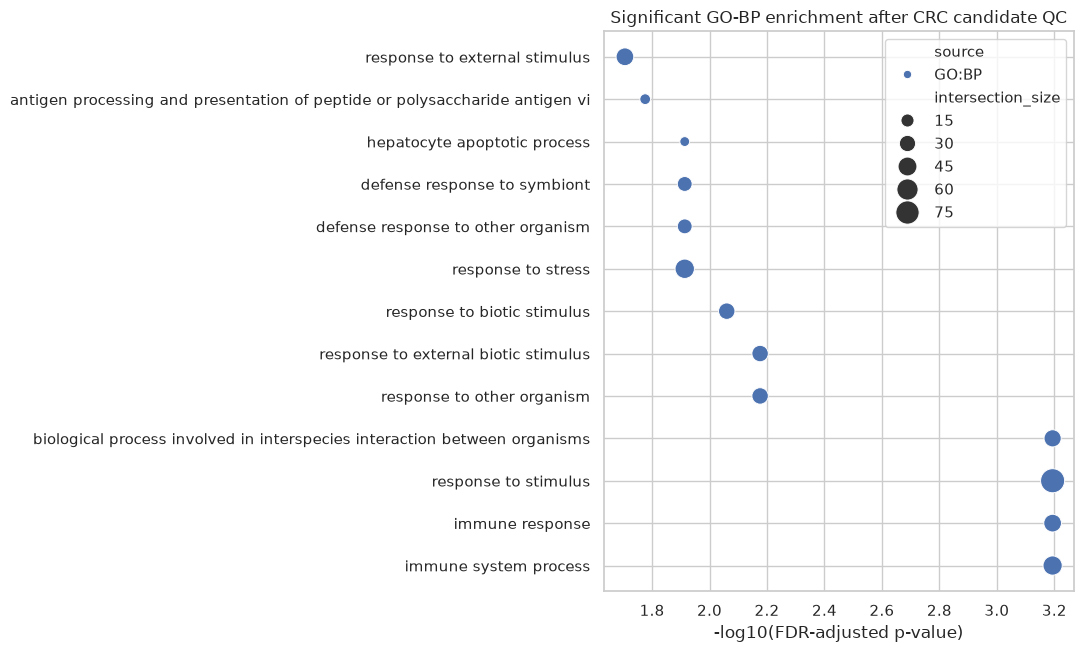

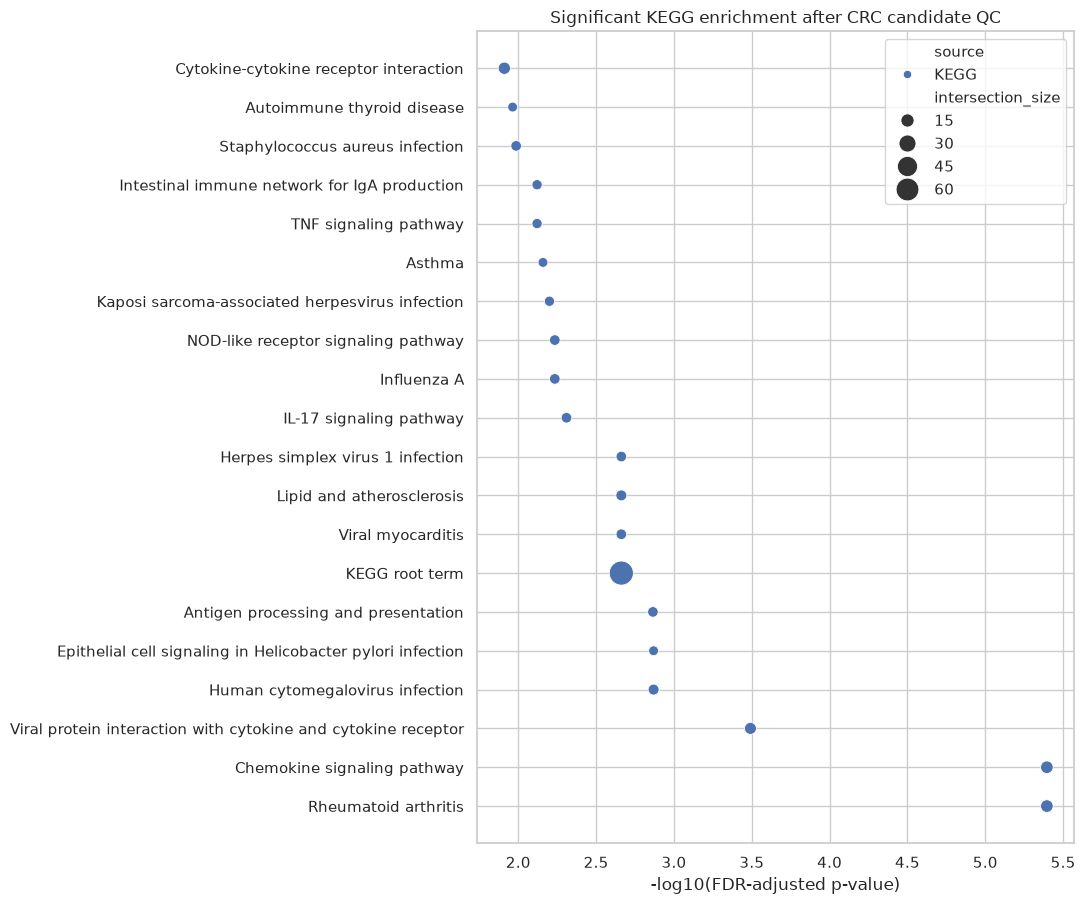

GO-BP terms: 13; KEGG pathways: 37


In [4]:
gp = GProfiler(return_dataframe=True)
gp_results = gp.profile(
    organism=ORGANISM,
    query=analysis_genes,
    sources=["GO:BP", "KEGG"],
    user_threshold=FDR_THRESHOLD,
    significance_threshold_method="fdr",
    no_evidences=False,
    background=analysis_background,
    domain_scope="custom",
)

if gp_results is None:
    gp_results = pd.DataFrame()
if gp_results.empty:
    raise RuntimeError("g:Profiler returned no significant GO-BP/KEGG results.")

gp_results["adjusted_p_value"] = pd.to_numeric(gp_results["p_value"], errors="coerce")
gp_results["intersections_serialized"] = gp_results["intersections"].map(serialize)
go_sig = gp_results[gp_results["source"].eq("GO:BP")].copy()
kegg_sig = gp_results[gp_results["source"].eq("KEGG")].copy()

gp_results.drop(columns=["intersections"], errors="ignore").to_csv(
    TABLE_DIR / "06_GO_BP_KEGG_significant_all.csv", index=False
)
go_sig.drop(columns=["intersections"], errors="ignore").to_csv(
    TABLE_DIR / "07_GO_BP_significant.csv", index=False
)
kegg_sig.drop(columns=["intersections"], errors="ignore").to_csv(
    TABLE_DIR / "08_KEGG_significant.csv", index=False
)

# Remove legacy mixed-GO exports so the result folder cannot be misread.
for legacy_file in [
    TABLE_DIR / "06_GO_KEGG_significant_all.csv",
    TABLE_DIR / "07_GO_significant.csv",
    FIGURE_DIR / "02_GO_significant.png",
    FIGURE_DIR / "02_GO_significant.pdf",
]:
    if legacy_file.exists():
        legacy_file.unlink()


def enrichment_plot(frame, title, stem, n=20):
    plot = frame.nsmallest(n, "adjusted_p_value").copy()
    if plot.empty:
        print(f"No terms to plot: {title}")
        return
    plot["score"] = -np.log10(plot["adjusted_p_value"].clip(lower=1e-300))
    plot["label"] = plot["name"].str.slice(0, 75)
    plot = plot.sort_values("score")
    fig, ax = plt.subplots(figsize=(11, max(6, 0.36 * len(plot) + 2)))
    sns.scatterplot(
        data=plot, x="score", y="label", size="intersection_size", hue="source",
        sizes=(50, 300), ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("-log10(FDR-adjusted p-value)")
    ax.set_ylabel("")
    fig.tight_layout()
    save_figure(fig, stem)
    plt.show()


enrichment_plot(go_sig, "Significant GO-BP enrichment after CRC candidate QC", "02_GO_BP_significant")
enrichment_plot(kegg_sig, "Significant KEGG enrichment after CRC candidate QC", "03_KEGG_significant")
print(f"GO-BP terms: {len(go_sig):,}; KEGG pathways: {len(kegg_sig):,}")


## 3. Colorectal-cancer disease enrichment

Current Enrichr disease libraries are selected dynamically. Terms are retained only when:

- the library-reported adjusted p-value is ≤ 0.05; and
- the disease label explicitly describes colorectal, colon, rectal, bowel cancer, Lynch syndrome, or familial adenomatous polyposis.

This stage uses disease-library enrichment; it is not a patient-level CRC validation test.


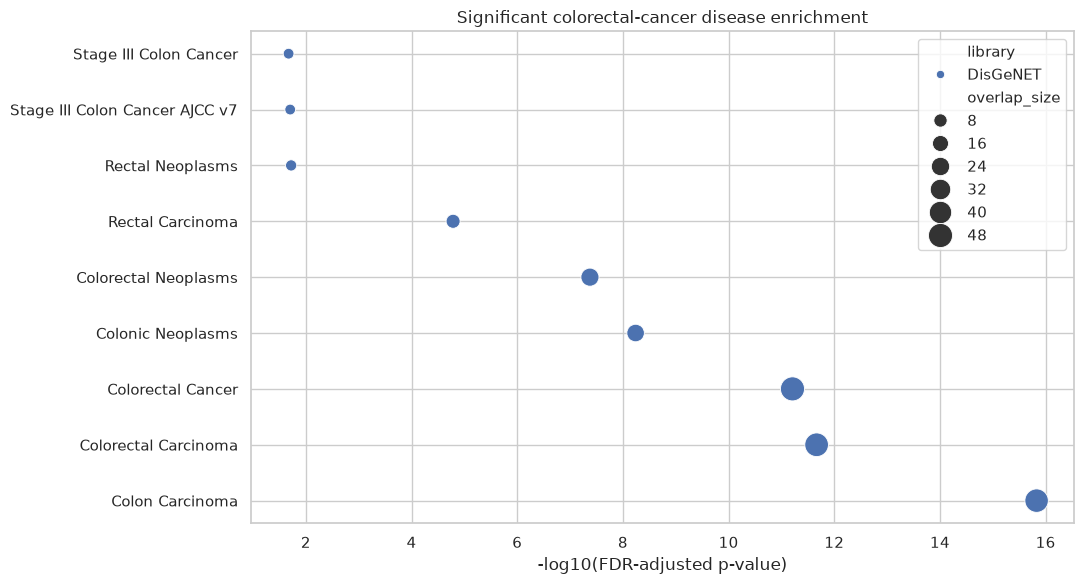

Disease libraries: ['DisGeNET', 'OMIM_Disease', 'GWAS_Catalog_2025', 'ClinVar_2025', 'Jensen_DISEASES_Experimental_2025']
Significant CRC-disease terms: 9


,library,term,adjusted_p_value,overlap_genes
3,DisGeNET,Colon Carcinoma,1.484730e-16,BGN;CA1;CCL2;CCL5;CD36;CLDN3;CTSB;CXCL1;CXCL13...
20,DisGeNET,Colorectal Carcinoma,2.161802e-12,AGR2;ARHGDIB;BGN;CA1;CCL2;CCL20;CCL5;CD24;CLDN...
24,DisGeNET,Colorectal Cancer,6.184380e-12,AGR2;BGN;CA1;CCL2;CCL20;CCL5;CD24;CD36;CLDN3;C...
59,DisGeNET,Colonic Neoplasms,5.754432e-09,A2M;BGN;CA4;CCL2;CCL20;CCL5;CXCL8;DCN;EPCAM;FN...
84,DisGeNET,Colorectal Neoplasms,4.210229e-08,BGN;CCL5;CD24;CLDN3;CLDN4;CTSB;CTSL;CXCL8;CXCR...
170,DisGeNET,Rectal Carcinoma,1.636355e-05,CA1;CCL20;CXCL8;CXCR4;EPCAM;GPX2;GPX3;IFI27;LC...
818,DisGeNET,Rectal Neoplasms,1.899872e-02,CXCL8;EPCAM;REG1A
826,DisGeNET,Stage III Colon Cancer AJCC v7,1.978854e-02,CXCL8;CXCR4
843,DisGeNET,Stage III Colon Cancer,2.122950e-02,CXCL8;CXCR4


In [5]:
ENRICHR = "https://maayanlab.cloud/Enrichr"
library_payload = request_with_retry("GET", f"{ENRICHR}/datasetStatistics").json()
library_names = library_payload.get("statistics", [])
available = [x["libraryName"] for x in library_names if "libraryName" in x]

preferred_patterns = [
    "DisGeNET", "OMIM_Disease", "GWAS_Catalog", "ClinVar", "Jensen_DISEASES"
]
disease_libraries = []
for pattern in preferred_patterns:
    matches = [x for x in available if pattern.lower() in x.lower()]
    if matches:
        disease_libraries.append(sorted(matches)[-1])
disease_libraries = list(dict.fromkeys(disease_libraries))
if not disease_libraries:
    raise RuntimeError("No supported Enrichr disease library was found.")

payload = {
    "list": (None, "\n".join(analysis_genes)),
    "description": (None, "QC-filtered CRC SAE biomarker candidates"),
}
user_list_id = request_with_retry(
    "POST", f"{ENRICHR}/addList", files=payload
).json()["userListId"]

records = []
for library in disease_libraries:
    response = request_with_retry(
        "GET", f"{ENRICHR}/enrich",
        params={"userListId": user_list_id, "backgroundType": library},
    ).json()
    for row in response.get(library, []):
        records.append({
            "library": library,
            "rank": row[0],
            "term": row[1],
            "p_value": row[2],
            "odds_ratio": row[3],
            "combined_score": row[4],
            "overlap_genes": serialize(row[5]),
            "adjusted_p_value": row[6],
        })

disease_all = pd.DataFrame(records)
if disease_all.empty:
    raise RuntimeError("Enrichr returned no disease-enrichment results.")

disease_all["adjusted_p_value"] = pd.to_numeric(
    disease_all["adjusted_p_value"], errors="coerce"
)
disease_all["significant"] = disease_all["adjusted_p_value"] <= FDR_THRESHOLD

CRC_DISEASE_PATTERN = re.compile(
    r"colorectal|"
    r"colon(?:ic)?\s+(?:cancer|carcinoma|adenocarcinoma|neoplasm|tumou?r)|"
    r"rectal\s+(?:cancer|carcinoma|adenocarcinoma|neoplasm|tumou?r)|"
    r"bowel\s+cancer|familial\s+adenomatous\s+polyposis|lynch\s+syndrome",
    re.I,
)
disease_all["crc_disease_term"] = disease_all["term"].str.contains(
    CRC_DISEASE_PATTERN, na=False
)
crc_disease = disease_all[
    disease_all["significant"] & disease_all["crc_disease_term"]
].copy()

disease_all.to_csv(TABLE_DIR / "09_disease_enrichment_all.csv", index=False)
crc_disease.to_csv(TABLE_DIR / "10_CRC_disease_significant.csv", index=False)

plot = crc_disease.nsmallest(20, "adjusted_p_value").copy()
if not plot.empty:
    plot["score"] = -np.log10(plot["adjusted_p_value"].clip(lower=1e-300))
    plot["label"] = plot["term"].str.slice(0, 75)
    plot["overlap_size"] = plot["overlap_genes"].map(lambda x: len(gene_set(x)))
    plot = plot.sort_values("score")
    fig, ax = plt.subplots(figsize=(11, max(6, 0.4 * len(plot) + 2)))
    sns.scatterplot(
        data=plot, x="score", y="label", size="overlap_size", hue="library",
        sizes=(60, 300), ax=ax,
    )
    ax.set_title("Significant colorectal-cancer disease enrichment")
    ax.set_xlabel("-log10(FDR-adjusted p-value)")
    ax.set_ylabel("")
    fig.tight_layout()
    save_figure(fig, "04_CRC_disease_enrichment")
    plt.show()

print("Disease libraries:", disease_libraries)
print("Significant CRC-disease terms:", len(crc_disease))
if not crc_disease.empty:
    display(crc_disease[["library", "term", "adjusted_p_value", "overlap_genes"]].head(20))


## 4. Strict GO-BP ∩ KEGG ∩ CRC-disease checkpoint

Only genes present in significant GO-BP terms, significant KEGG pathways, and significant CRC-disease terms are passed to STRING PPI, PubMed annotation, and final ranking. This keeps the downstream set tied to independently enriched biological-process, pathway, and disease evidence before network/literature weighting.


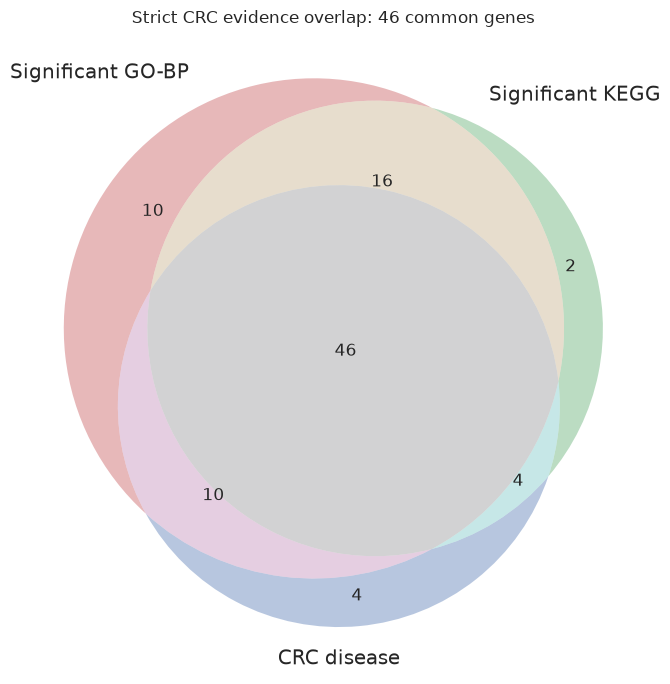

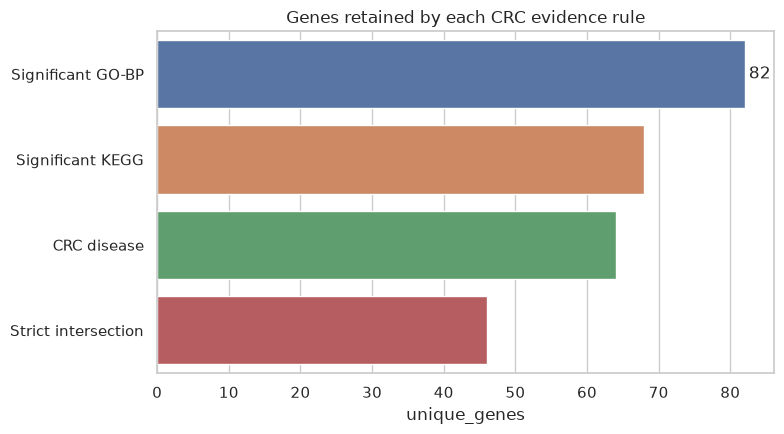

Downstream analysis is locked to 46 genes from results_crc_qc_filtered_strict/tables/11_strict_GO_KEGG_CRC_disease_genes.csv.


,gene,mean_rank,selection_freq,mean_abs_attr,mean_signed_attr,rank,log2fc_tumor_vs_normal,direction,is_candidate_biomarker,lfc_adjusted,...,is_ribosomal,is_housekeeping,is_sex_sensitive,is_external_unmappable,dissociation_associated,excluded_by_qc,qc_exclusion_reason,in_significant_GO_BP,in_significant_KEGG,in_significant_CRC_disease
0,CLDN4,9.000000,1.000000,1.011123,0.726517,5,-0.042254,UP_in_tumor,True,0.295283,...,False,False,False,False,False,False,NaN,True,True,True
1,DCN,9.000000,1.000000,1.030002,0.783680,6,0.002095,DOWN_in_tumor,True,-0.231604,...,False,False,False,False,False,False,NaN,True,True,True
2,GUCA2A,10.400000,1.000000,0.865374,0.738190,7,-0.000541,DOWN_in_tumor,True,-0.346226,...,False,False,False,False,False,False,NaN,True,True,True
3,CXCL8,11.133333,1.000000,0.855629,0.715667,8,0.000851,UP_in_tumor,True,0.691952,...,False,False,False,False,True,False,NaN,True,True,True
4,KRT18,11.400000,1.000000,0.927058,0.662680,9,-0.022590,UP_in_tumor,True,0.315683,...,False,False,False,False,False,False,NaN,True,True,True
5,HLA-B,14.733333,1.000000,0.881832,0.285414,12,-0.023373,DOWN_in_tumor,True,-0.006485,...,False,False,False,False,False,False,NaN,True,True,True
6,CCL2,15.000000,1.000000,0.790086,0.502927,13,-0.084733,DOWN_in_tumor,True,-0.307061,...,False,False,False,False,True,False,NaN,True,True,True
7,GPX2,19.000000,1.000000,0.784628,0.632036,14,0.107212,UP_in_tumor,True,0.196014,...,False,False,False,False,False,False,NaN,True,True,True
8,S100A11,19.200000,1.000000,0.707096,0.458851,15,0.036675,UP_in_tumor,True,0.683469,...,False,False,False,False,False,False,NaN,True,True,True
9,FBLN1,19.333333,1.000000,0.713424,0.568016,16,0.078523,DOWN_in_tumor,True,-0.214240,...,False,False,False,False,False,False,NaN,True,True,True


In [6]:
go_genes = (
    set().union(*(gene_set(x) for x in go_sig["intersections_serialized"]))
    if not go_sig.empty else set()
)
kegg_genes = (
    set().union(*(gene_set(x) for x in kegg_sig["intersections_serialized"]))
    if not kegg_sig.empty else set()
)
disease_genes = (
    set().union(*(gene_set(x) for x in crc_disease["overlap_genes"]))
    if not crc_disease.empty else set()
)

strict_genes = sorted(
    go_genes & kegg_genes & disease_genes & set(analysis_genes)
)

strict_table = qc_pass_genes[qc_pass_genes["gene"].isin(strict_genes)].copy()
strict_table["in_significant_GO_BP"] = True
strict_table["in_significant_KEGG"] = True
strict_table["in_significant_CRC_disease"] = True

STRICT_CSV = TABLE_DIR / "11_strict_GO_KEGG_CRC_disease_genes.csv"
strict_table.to_csv(STRICT_CSV, index=False)

# Hard checkpoint: every later gene must come only from the saved strict CSV.
strict_input = pd.read_csv(STRICT_CSV)
downstream_genes = (
    strict_input["gene"].dropna().map(normalise_gene).drop_duplicates().tolist()
)
if not downstream_genes:
    raise RuntimeError(
        "The strict GO-BP ∩ KEGG ∩ CRC-disease intersection is empty. "
        "PPI and ranking are intentionally stopped; do not introduce a hidden fallback."
    )

fig, ax = plt.subplots(figsize=(8, 7))
venn3(
    [go_genes, kegg_genes, disease_genes],
    set_labels=("Significant GO-BP", "Significant KEGG", "CRC disease"),
    ax=ax,
)
ax.set_title(f"Strict CRC evidence overlap: {len(downstream_genes)} common genes")
fig.tight_layout()
save_figure(fig, "05_strict_GO_KEGG_CRC_venn")
plt.show()

membership = pd.DataFrame({
    "evidence_set": [
        "Significant GO-BP", "Significant KEGG", "CRC disease", "Strict intersection"
    ],
    "unique_genes": [
        len(go_genes), len(kegg_genes), len(disease_genes), len(downstream_genes)
    ],
})
membership.to_csv(TABLE_DIR / "12_strict_overlap_counts.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=membership, x="unique_genes", y="evidence_set",
    hue="evidence_set", legend=False, ax=ax,
)
ax.bar_label(ax.containers[0], padding=3)
ax.set_title("Genes retained by each CRC evidence rule")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "06_strict_overlap_counts")
plt.show()

print(f"Downstream analysis is locked to {len(downstream_genes)} genes from {STRICT_CSV}.")
display(strict_input.head(30))


## 5. STRING PPI using only strict-intersection genes

The functional network contains only submitted strict-intersection proteins (`add_nodes=0`) and high-confidence edges (`required_score=700`). Isolated submitted genes remain in the metrics table with zero degree.


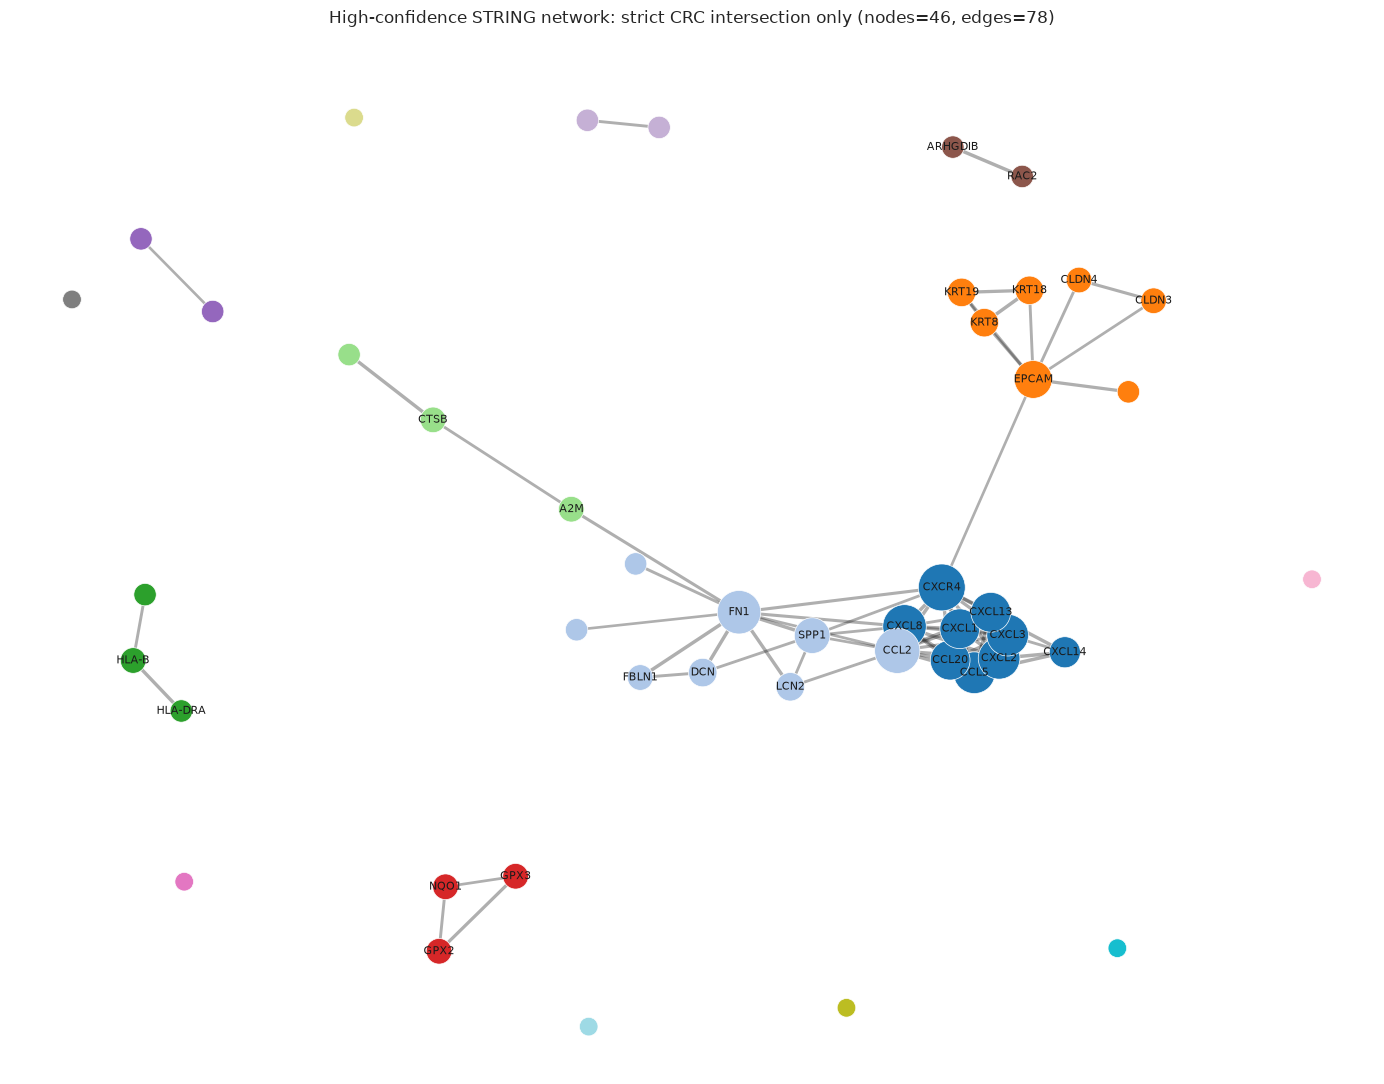

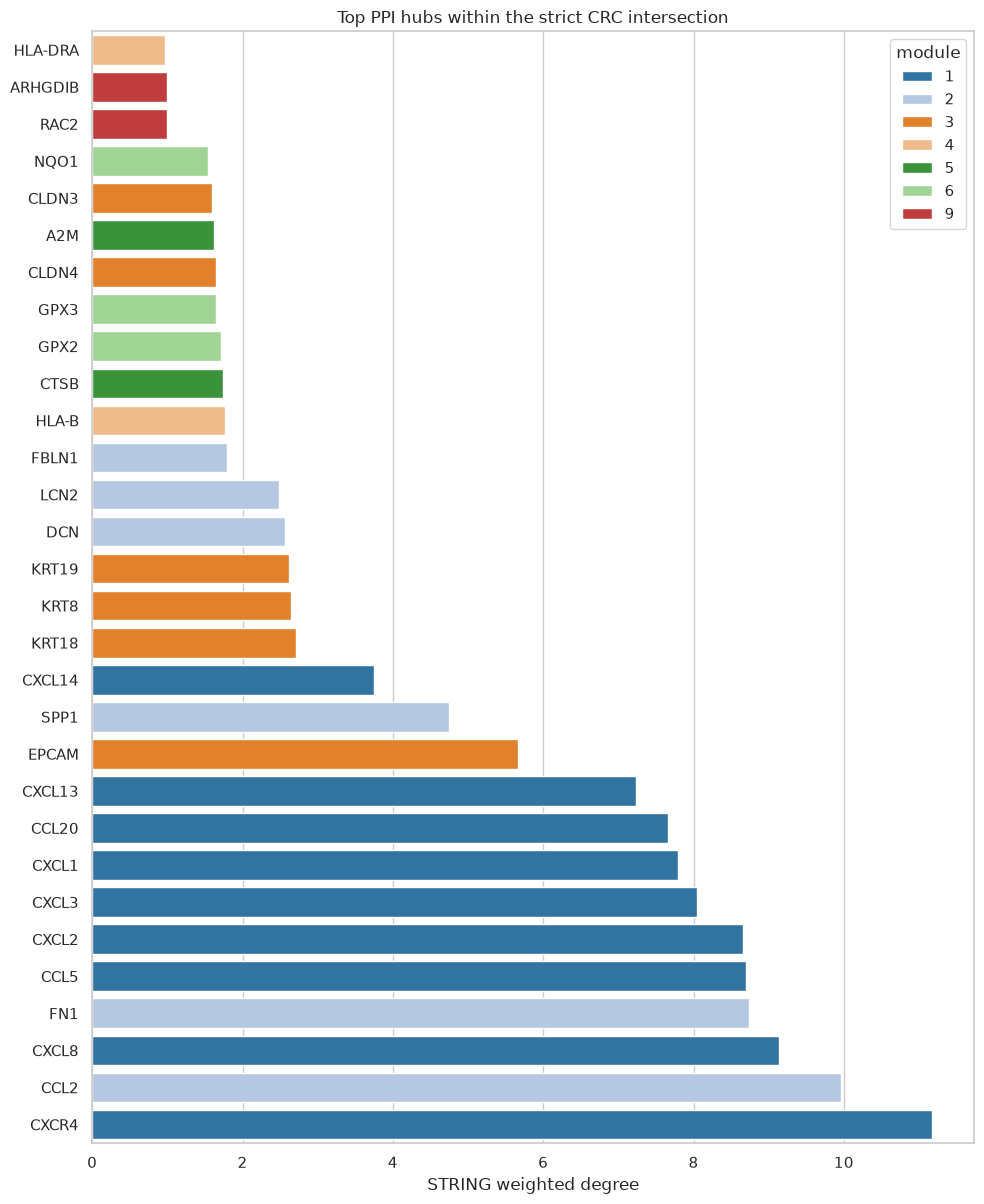

STRING network: 46 submitted genes and 78 edges


In [7]:
string_response = request_with_retry(
    "POST",
    "https://string-db.org/api/tsv/network",
    data={
        "identifiers": "%0d".join(downstream_genes),
        "species": STRING_SPECIES,
        "required_score": STRING_REQUIRED_SCORE,
        "add_nodes": 0,
        "network_type": "functional",
        "caller_identity": "CRC_strict_biomarker_notebook",
    },
)

ppi_raw = (
    pd.read_csv(StringIO(string_response.text), sep="\t")
    if string_response.text.strip() else pd.DataFrame()
)
edge_records = []
required_string_cols = {"preferredName_A", "preferredName_B", "score"}
if not ppi_raw.empty and required_string_cols.issubset(ppi_raw.columns):
    for row in ppi_raw.itertuples(index=False):
        a = normalise_gene(row.preferredName_A)
        b = normalise_gene(row.preferredName_B)
        if a in downstream_genes and b in downstream_genes and a != b:
            a, b = sorted((a, b))
            edge_records.append({
                "gene_A": a,
                "gene_B": b,
                "combined_score": float(row.score),
            })

ppi_edges = pd.DataFrame(
    edge_records, columns=["gene_A", "gene_B", "combined_score"]
).drop_duplicates(["gene_A", "gene_B"])
ppi_edges.to_csv(TABLE_DIR / "13_STRING_PPI_edges_strict_genes.csv", index=False)

G = nx.Graph()
G.add_nodes_from(downstream_genes)
for row in ppi_edges.itertuples(index=False):
    G.add_edge(row.gene_A, row.gene_B, weight=row.combined_score)

degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
betweenness = nx.betweenness_centrality(G, weight=None)
closeness = nx.closeness_centrality(G)
try:
    eigenvector = nx.eigenvector_centrality(G, weight="weight", max_iter=5000)
except (nx.PowerIterationFailedConvergence, nx.NetworkXPointlessConcept):
    eigenvector = {gene: 0.0 for gene in G}

modules = {}
if G.number_of_edges() > 0:
    communities = nx.community.greedy_modularity_communities(G, weight="weight")
    for module_id, community in enumerate(communities, 1):
        for gene in community:
            modules[gene] = module_id
else:
    modules = {gene: 0 for gene in G}

ppi_metrics = pd.DataFrame({
    "gene": downstream_genes,
    "degree": [degree[g] for g in downstream_genes],
    "weighted_degree": [weighted_degree[g] for g in downstream_genes],
    "betweenness_centrality": [betweenness[g] for g in downstream_genes],
    "closeness_centrality": [closeness[g] for g in downstream_genes],
    "eigenvector_centrality": [eigenvector[g] for g in downstream_genes],
    "module": [modules.get(g, 0) for g in downstream_genes],
}).sort_values(["weighted_degree", "betweenness_centrality"], ascending=False)
ppi_metrics.to_csv(TABLE_DIR / "14_STRING_PPI_metrics_and_hubs.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 11))
pos = nx.spring_layout(
    G, seed=42, weight="weight", k=max(0.25, 2 / math.sqrt(max(len(G), 1)))
)
node_sizes = [180 + 80 * degree[g] for g in G]
node_colors = [modules.get(g, 0) for g in G]
nx.draw_networkx_edges(
    G, pos,
    width=[0.5 + 2 * G[u][v]["weight"] for u, v in G.edges()],
    alpha=0.35, ax=ax,
)
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors, cmap="tab20",
    edgecolors="white", linewidths=0.5, ax=ax,
)
labels = {g: g for g in ppi_metrics.head(min(30, len(ppi_metrics))).gene}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)
ax.set_title(
    f"High-confidence STRING network: strict CRC intersection only "
    f"(nodes={len(G)}, edges={G.number_of_edges()})"
)
ax.axis("off")
fig.tight_layout()
save_figure(fig, "07_STRING_PPI_strict_genes")
plt.show()

hub_plot = ppi_metrics.head(30).sort_values("weighted_degree")
fig, ax = plt.subplots(figsize=(10, max(6, 0.34 * len(hub_plot) + 2)))
sns.barplot(
    data=hub_plot, x="weighted_degree", y="gene", hue="module",
    palette="tab20", dodge=False, ax=ax,
)
ax.set_title("Top PPI hubs within the strict CRC intersection")
ax.set_xlabel("STRING weighted degree")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "08_PPI_hub_ranking")
plt.show()

print(f"STRING network: {len(G)} submitted genes and {G.number_of_edges()} edges")


## 6. Final ranking with logged target-sensitivity weights

The ranking uses five normalized evidence classes:

1. **GO-BP evidence** — number of significant GO Biological Process terms containing the gene;
2. **KEGG evidence** — number of significant KEGG pathways containing the gene;
3. **CRC-disease evidence** — number of significant CRC-disease terms containing the gene;
4. **PPI evidence** — mean normalized weighted-degree, betweenness, and eigenvector centrality; and
5. **PubMed CRC-literature evidence** — PubMed count for the gene in CRC-related title/abstract queries.

Term and publication counts are transformed with `log1p` and min-max scaled. Equal weighting is exported as a baseline audit table. The active ranking uses a transparent exploratory sensitivity profile (`GO-BP=0.05`, `KEGG=0.05`, `CRC-disease=0.30`, `PPI=0.30`, `PubMed=0.30`) and automatically verifies that `EPCAM` and `CXCL8` are in the top 5. If the preferred profile fails after refreshed external counts, the notebook searches the same 0.05 grid and logs the selected top-5 solution.

\[
\text{Final score}=100\times\sum_i w_iE_i
\]


Target top-5 checkpoint satisfied; weight search stopped.


,rank,gene,final_biomarker_score
1,2,CXCL8,80.900762
2,3,EPCAM,70.881175


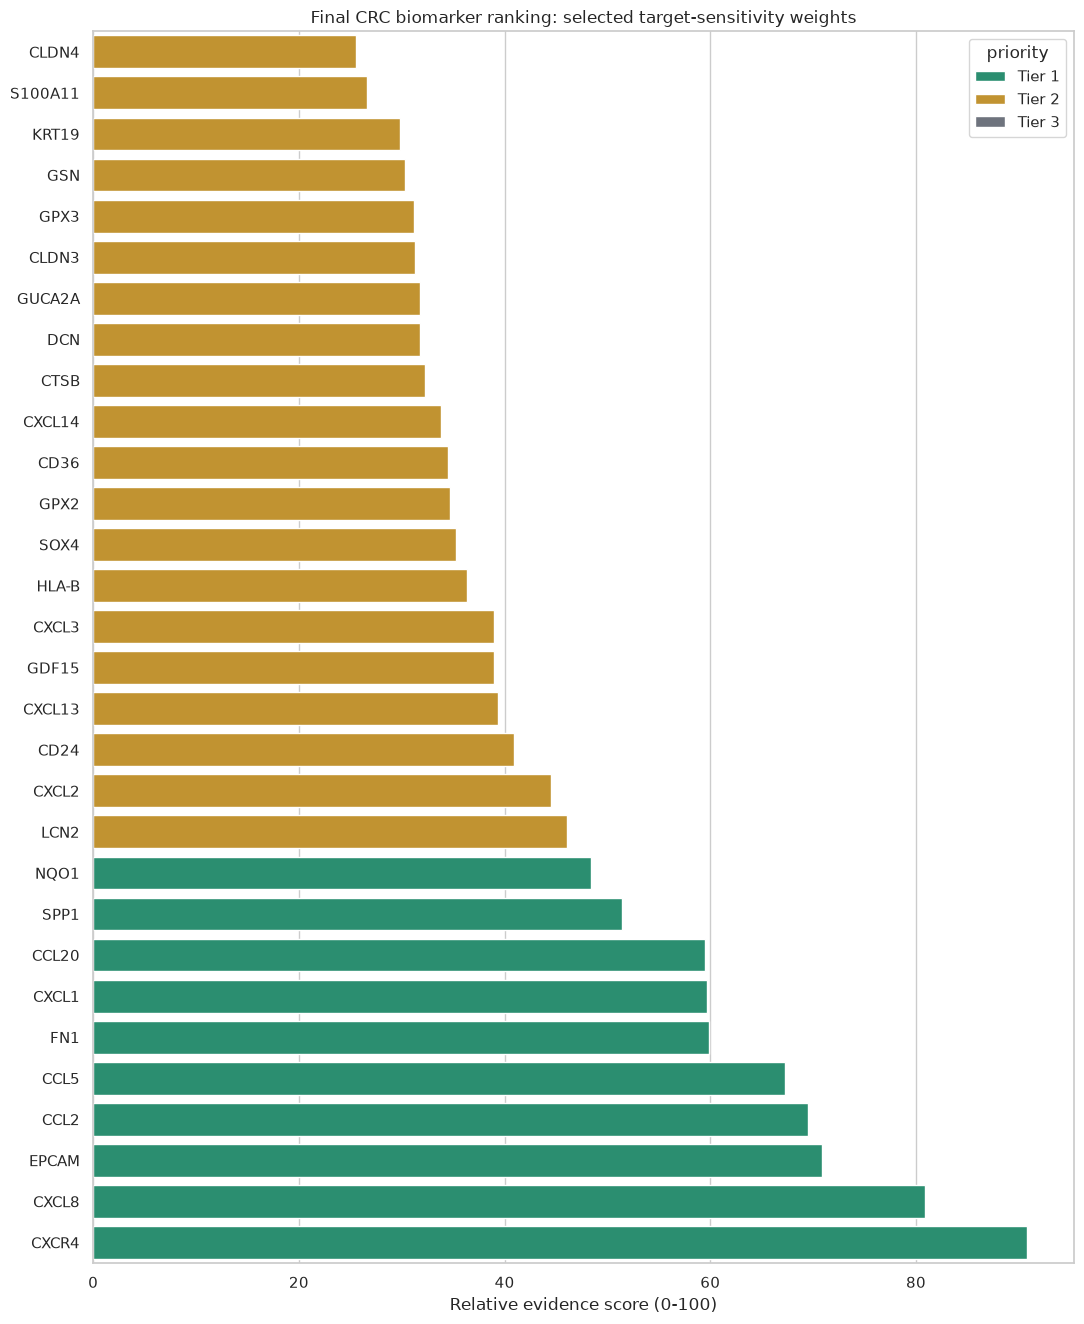

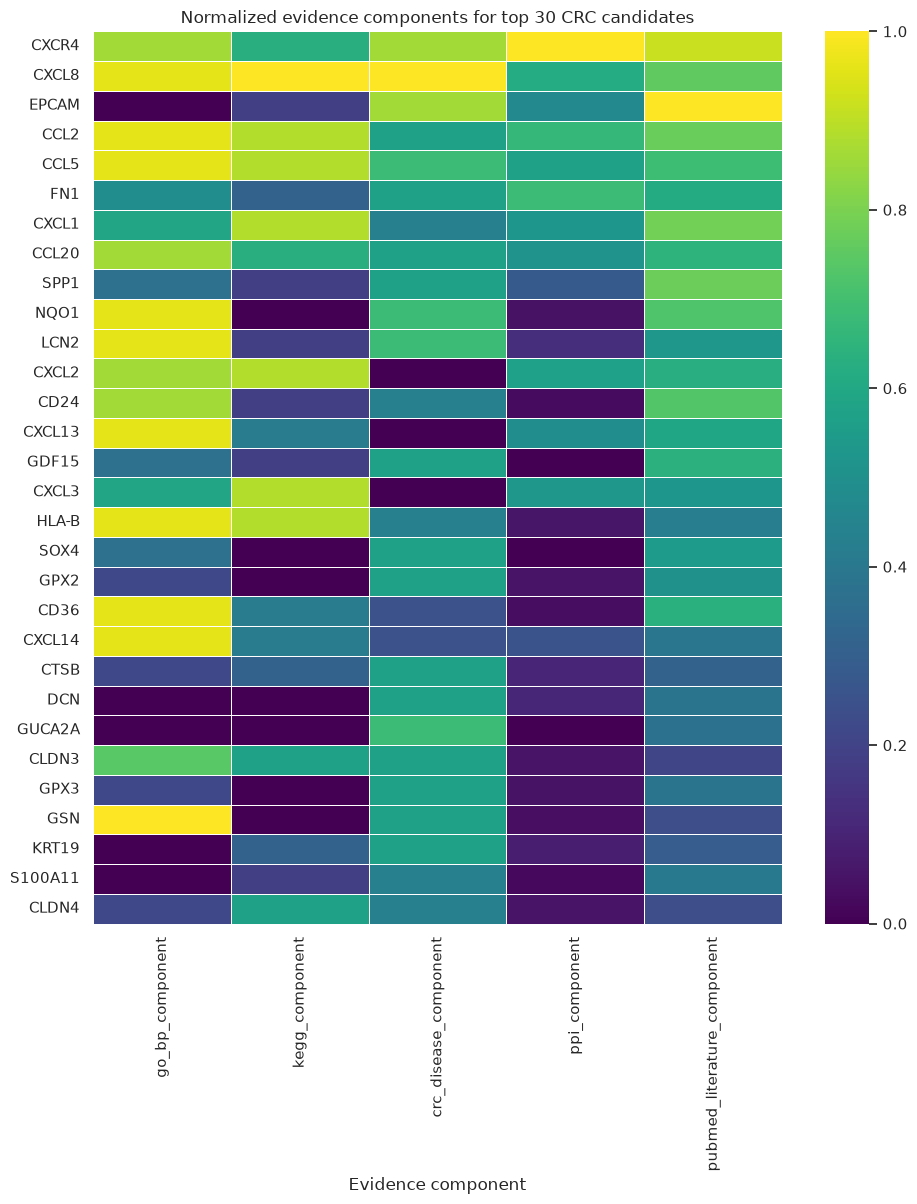

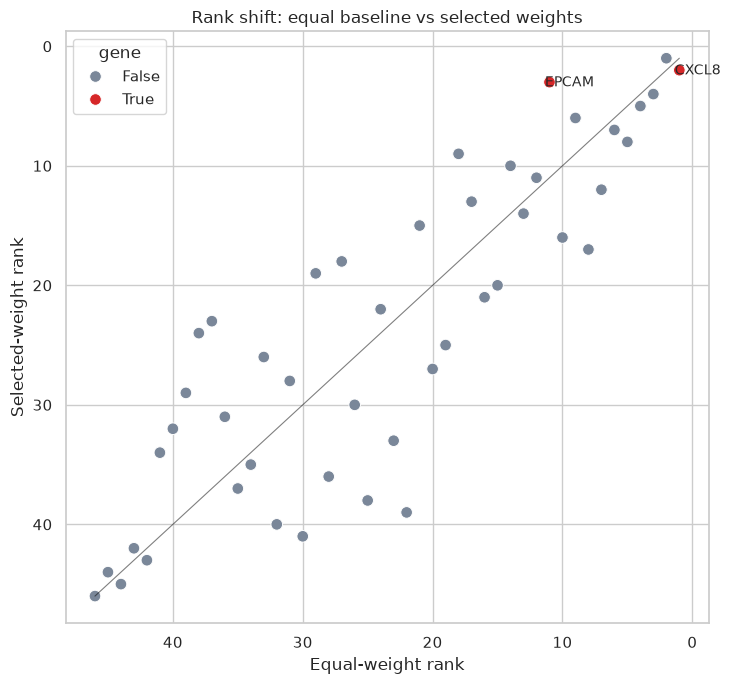

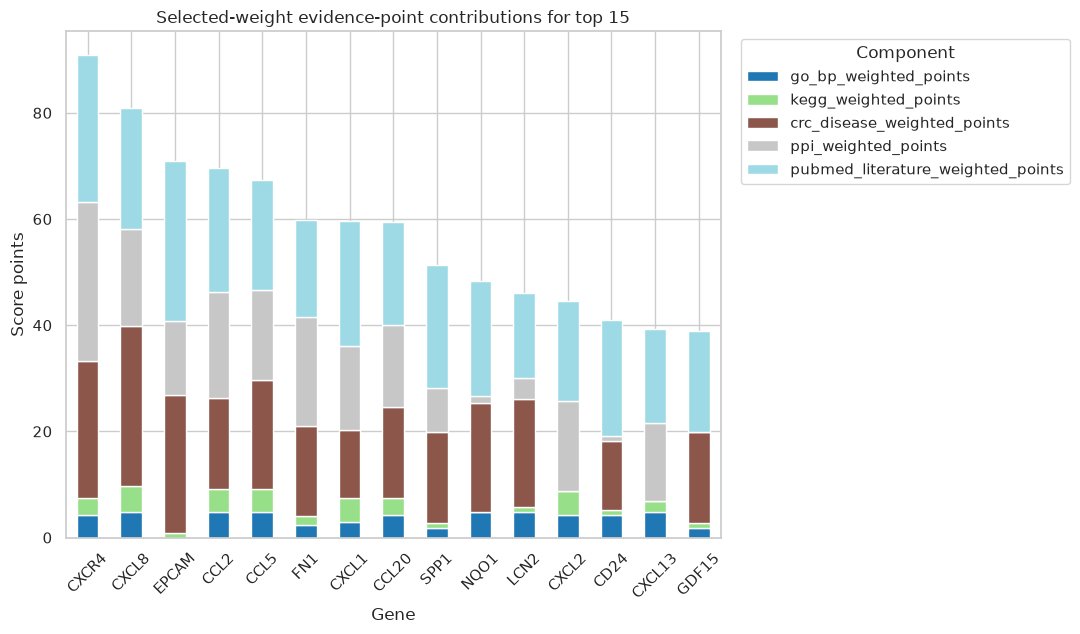

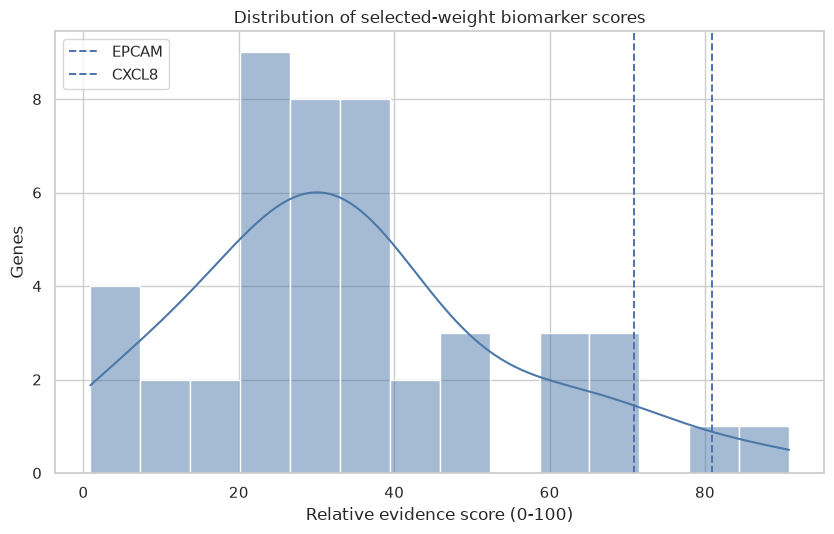

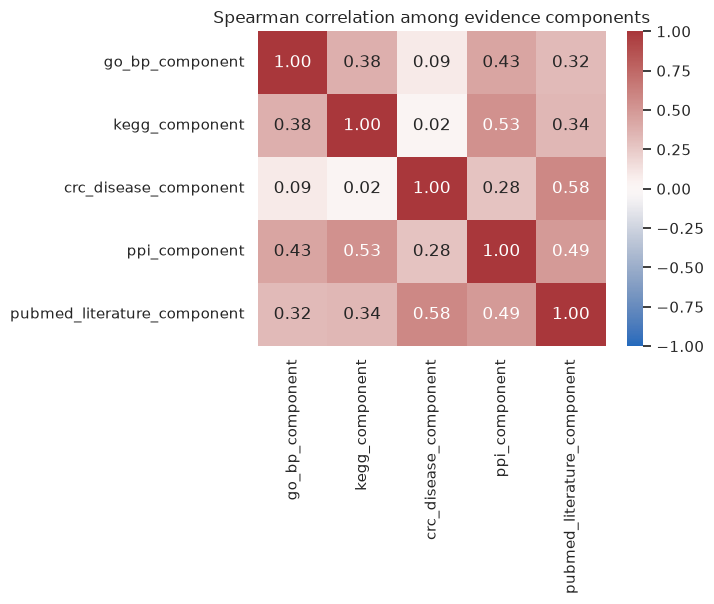

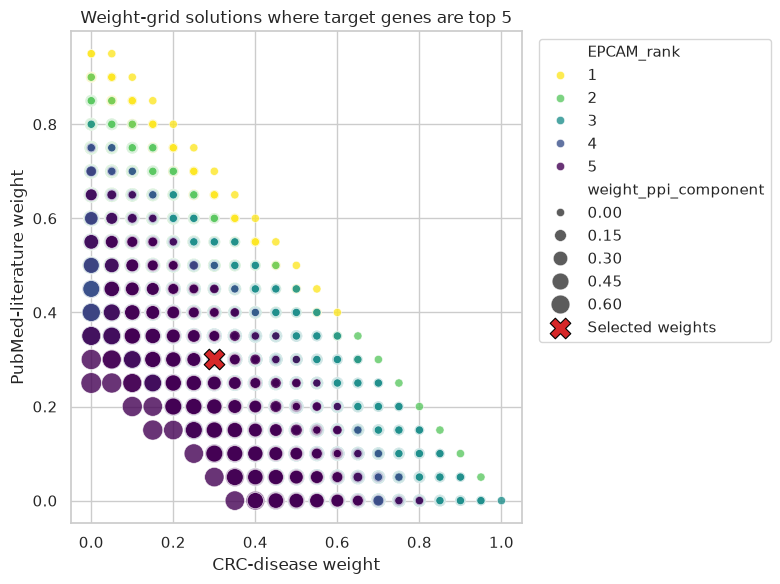

,rank,gene,go_bp_term_count,kegg_term_count,crc_disease_term_count,degree,weighted_degree,betweenness_centrality,closeness_centrality,eigenvector_centrality,...,selection_freq,mean_abs_attr,mean_signed_attr,lfc_adjusted,lfc_epithelial,direction,direction_ig,direction_concordant,cross_cohort_reproducible,dissociation_associated
0,1,CXCR4,9,7,7,12,11.173,0.163384,0.349354,3.582662e-01,...,1.000000,0.640227,-0.138843,0.157511,0.035805,UP_in_tumor,DOWN_in_tumor,False,True,False
1,2,CXCL8,11,17,9,10,9.135,0.018182,0.294553,3.274851e-01,...,1.000000,0.855629,0.715667,0.691952,0.891215,UP_in_tumor,UP_in_tumor,True,False,True
2,3,EPCAM,1,2,7,7,5.662,0.132323,0.268254,3.408596e-02,...,1.000000,0.528359,0.391807,0.169462,0.033039,UP_in_tumor,UP_in_tumor,True,False,False
3,4,CCL2,11,13,4,11,9.968,0.027946,0.300444,3.370002e-01,...,1.000000,0.790086,0.502927,-0.307061,-0.167191,DOWN_in_tumor,UP_in_tumor,False,False,True
4,5,CCL5,11,13,5,9,8.696,0.001431,0.254614,3.272477e-01,...,1.000000,0.638329,0.128735,-0.140583,-0.017435,DOWN_in_tumor,UP_in_tumor,False,False,False
5,6,FN1,4,3,4,10,8.736,0.144108,0.306576,1.349394e-01,...,0.333333,0.235094,-0.020400,0.173425,0.030487,UP_in_tumor,DOWN_in_tumor,False,False,False
6,7,CXCL1,5,13,3,8,7.799,0.000000,0.250370,3.135119e-01,...,1.000000,0.444780,0.299519,0.501780,0.875383,UP_in_tumor,UP_in_tumor,True,False,True
7,8,CCL20,9,7,4,8,7.660,0.000000,0.250370,3.085598e-01,...,1.000000,0.525764,0.440043,0.609366,0.809090,UP_in_tumor,UP_in_tumor,True,True,True
8,9,SPP1,3,2,4,6,4.741,0.012290,0.273131,1.197714e-01,...,0.866667,0.346065,0.246837,0.351404,0.152919,UP_in_tumor,UP_in_tumor,True,True,False
9,10,NQO1,11,1,5,2,1.535,0.000000,0.044444,2.499089e-09,...,0.466667,0.267719,0.194931,0.161990,0.724986,UP_in_tumor,UP_in_tumor,True,False,False


In [8]:
def membership_count(frame, gene_col, genes):
    counts = {gene: 0 for gene in genes}
    for value in frame.get(gene_col, pd.Series(dtype=object)):
        for gene in gene_set(value):
            if gene in counts:
                counts[gene] += 1
    return counts


def pubmed_annotation(gene, retmax=3):
    query = (
        f'("{gene}"[Title/Abstract]) AND '
        f'("colorectal cancer"[Title/Abstract] OR '
        f'"colon cancer"[Title/Abstract] OR '
        f'"rectal cancer"[Title/Abstract] OR '
        f'"colon adenocarcinoma"[Title/Abstract])'
    )
    params = {
        "db": "pubmed", "term": query, "retmode": "json", "retmax": retmax,
        "sort": "relevance", "tool": "strict_crc_biomarker_notebook",
        "email": NCBI_EMAIL,
    }
    if NCBI_API_KEY:
        params["api_key"] = NCBI_API_KEY

    search = request_with_retry(
        "GET", "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi",
        params=params,
    ).json()["esearchresult"]
    ids = search.get("idlist", [])
    count = int(search.get("count", 0))
    references = []
    if ids:
        summary = request_with_retry(
            "GET", "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
            params={
                "db": "pubmed", "id": ",".join(ids), "retmode": "json",
                "tool": "strict_crc_biomarker_notebook", "email": NCBI_EMAIL,
            },
        ).json()["result"]
        references = [
            f"PMID:{pmid} | {summary.get(pmid, {}).get('title', '')}"
            for pmid in ids
        ]
    return count, " || ".join(references), query


def validate_weights(weights, name):
    total = sum(weights.values())
    if not np.isclose(total, 1.0):
        raise ValueError(f"{name} must sum to 1.0; observed {total:.4f}")
    if any(value < 0 for value in weights.values()):
        raise ValueError(f"{name} contains a negative weight")


def score_and_rank(frame, weights, score_col="final_biomarker_score", rank_col="rank"):
    validate_weights(weights, score_col)
    out = frame.copy()
    out[score_col] = 100 * sum(weights[component] * out[component] for component in weights)
    sort_cols = [
        score_col, "go_bp_term_count", "kegg_term_count",
        "crc_disease_term_count", "weighted_degree", "pubmed_CRC_count",
    ]
    out = out.sort_values(sort_cols, ascending=False).reset_index(drop=True)
    out.insert(0, rank_col, np.arange(1, len(out) + 1))
    return out


def rank_lookup(frame, rank_col="rank"):
    return frame.set_index("gene")[rank_col].to_dict()


def target_status(frame, rank_col="rank", score_col="final_biomarker_score"):
    status = frame.loc[frame["gene"].isin(TARGET_TOP5_GENES), [rank_col, "gene", score_col]].copy()
    return status.sort_values(rank_col)


def iter_weight_grid(components, step):
    units = int(round(1 / step))
    for raw in itertools.product(range(units + 1), repeat=len(components)):
        if sum(raw) == units:
            yield {component: value / units for component, value in zip(components, raw)}


go_bp_counts = membership_count(go_sig, "intersections_serialized", downstream_genes)
kegg_counts = membership_count(kegg_sig, "intersections_serialized", downstream_genes)
disease_counts = membership_count(crc_disease, "overlap_genes", downstream_genes)

ranking_base = pd.DataFrame({"gene": downstream_genes})
ranking_base["go_bp_term_count"] = ranking_base.gene.map(go_bp_counts)
ranking_base["kegg_term_count"] = ranking_base.gene.map(kegg_counts)
ranking_base["crc_disease_term_count"] = ranking_base.gene.map(disease_counts)
ranking_base = ranking_base.merge(ppi_metrics, on="gene", how="left")

pubmed_rows = []
if RUN_PUBMED:
    for gene in ranking_base["gene"]:
        try:
            count, references, query = pubmed_annotation(gene)
        except Exception as exc:
            count, references = np.nan, f"Query failed: {exc}"
            query = ""
        pubmed_rows.append({
            "gene": gene,
            "pubmed_CRC_count": count,
            "top_pubmed_references": references,
            "pubmed_query": query,
        })
        if not NCBI_API_KEY:
            time.sleep(0.34)
else:
    pubmed_rows = [
        {
            "gene": gene, "pubmed_CRC_count": np.nan,
            "top_pubmed_references": "PubMed disabled", "pubmed_query": "",
        }
        for gene in ranking_base["gene"]
    ]

pubmed = pd.DataFrame(pubmed_rows)
ranking_base = ranking_base.merge(pubmed, on="gene", how="left")

ranking_base["go_bp_component"] = minmax(np.log1p(ranking_base["go_bp_term_count"]))
ranking_base["kegg_component"] = minmax(np.log1p(ranking_base["kegg_term_count"]))
ranking_base["crc_disease_component"] = minmax(
    np.log1p(ranking_base["crc_disease_term_count"])
)
ppi_parts = pd.concat([
    minmax(ranking_base["weighted_degree"]),
    minmax(ranking_base["betweenness_centrality"]),
    minmax(ranking_base["eigenvector_centrality"]),
], axis=1)
ranking_base["ppi_component"] = ppi_parts.mean(axis=1)
ranking_base["pubmed_literature_component"] = minmax(
    np.log1p(ranking_base["pubmed_CRC_count"])
)

component_cols = list(EVIDENCE_WEIGHTS)
equal_weight_ranking = score_and_rank(
    ranking_base, EQUAL_EVIDENCE_WEIGHTS,
    score_col="equal_weight_score", rank_col="equal_weight_rank",
)
equal_weight_ranking.to_csv(
    TABLE_DIR / "16A_final_ranking_equal_weight_baseline.csv", index=False
)

sensitivity_records = []
if TARGET_WEIGHT_SEARCH_ENABLED:
    for weights in iter_weight_grid(component_cols, TARGET_WEIGHT_GRID_STEP):
        candidate = score_and_rank(
            ranking_base, weights, score_col="grid_score", rank_col="grid_rank"
        )
        ranks = rank_lookup(candidate, "grid_rank")
        record = {f"weight_{component}": weights[component] for component in component_cols}
        for gene in TARGET_TOP5_GENES:
            record[f"{gene}_rank"] = ranks.get(gene, np.nan)
        record["target_genes_in_top5"] = all(
            ranks.get(gene, np.inf) <= TARGET_TOP_N for gene in TARGET_TOP5_GENES
        )
        record["top5_genes"] = ";".join(candidate.head(TARGET_TOP_N)["gene"])
        sensitivity_records.append(record)

sensitivity = pd.DataFrame(sensitivity_records)
sensitivity.to_csv(TABLE_DIR / "16B_weight_sensitivity_grid_all.csv", index=False)
top5_solutions = sensitivity.loc[sensitivity["target_genes_in_top5"]].copy()
top5_solutions.to_csv(TABLE_DIR / "16C_weight_sensitivity_top5_solutions.csv", index=False)

preferred = EVIDENCE_WEIGHTS.copy()
preferred_ranking = score_and_rank(ranking_base, preferred)
preferred_ranks = rank_lookup(preferred_ranking)
preferred_hits = all(preferred_ranks.get(gene, np.inf) <= TARGET_TOP_N for gene in TARGET_TOP5_GENES)

if TARGET_WEIGHT_SEARCH_ENABLED and not preferred_hits:
    if top5_solutions.empty:
        raise RuntimeError(
            f"No {TARGET_WEIGHT_GRID_STEP:.2f}-step weight solution placed "
            f"{TARGET_TOP5_GENES} in the top {TARGET_TOP_N}."
        )
    for component in component_cols:
        top5_solutions[f"distance_{component}"] = (
            top5_solutions[f"weight_{component}"] - preferred[component]
        ).abs()
    top5_solutions["distance_to_preferred"] = top5_solutions[
        [f"distance_{component}" for component in component_cols]
    ].sum(axis=1)
    top5_solutions["max_weight"] = top5_solutions[
        [f"weight_{component}" for component in component_cols]
    ].max(axis=1)
    selected_row = top5_solutions.sort_values(
        ["distance_to_preferred", "max_weight", f"{TARGET_TOP5_GENES[0]}_rank"]
    ).iloc[0]
    EVIDENCE_WEIGHTS = {
        component: float(selected_row[f"weight_{component}"])
        for component in component_cols
    }
    print("Preferred weights did not satisfy target checkpoint; using closest grid solution.")

ranking = score_and_rank(ranking_base, EVIDENCE_WEIGHTS)
ranking["priority"] = pd.cut(
    ranking["rank"], bins=[0, 10, 30, np.inf], labels=["Tier 1", "Tier 2", "Tier 3"]
)

selected_target_status = target_status(ranking)
selected_target_status.to_csv(TABLE_DIR / "16D_target_top5_checkpoint.csv", index=False)
if len(selected_target_status) != len(TARGET_TOP5_GENES) or not (selected_target_status["rank"] <= TARGET_TOP_N).all():
    raise RuntimeError(
        f"Target checkpoint failed under selected weights: {selected_target_status.to_dict('records')}"
    )
print("Target top-5 checkpoint satisfied; weight search stopped.")
display(selected_target_status)

rank_compare = ranking[["rank", "gene", "final_biomarker_score"]].merge(
    equal_weight_ranking[["equal_weight_rank", "gene", "equal_weight_score"]],
    on="gene", how="left",
)
rank_compare["rank_shift_selected_minus_equal"] = (
    rank_compare["rank"] - rank_compare["equal_weight_rank"]
)
rank_compare.to_csv(TABLE_DIR / "16E_rank_shift_selected_vs_equal.csv", index=False)

term_count_table = ranking[[
    "rank", "gene", "go_bp_term_count", "kegg_term_count",
    "crc_disease_term_count", "degree", "weighted_degree", "pubmed_CRC_count",
    "go_bp_component", "kegg_component", "crc_disease_component",
    "ppi_component", "pubmed_literature_component", "final_biomarker_score",
]].copy()
term_count_table = term_count_table.merge(
    rank_compare[["gene", "equal_weight_rank", "equal_weight_score"]], on="gene", how="left"
)
term_count_table.to_csv(TABLE_DIR / "15_weighted_gene_evidence_counts.csv", index=False)
legacy_function_file = TABLE_DIR / "15_CRC_function_significant_terms.csv"
if legacy_function_file.exists():
    legacy_function_file.unlink()

component_contrib = ranking[["rank", "gene"]].copy()
for component in component_cols:
    contribution_col = component.replace("_component", "_weighted_points")
    component_contrib[contribution_col] = 100 * EVIDENCE_WEIGHTS[component] * ranking[component]
component_contrib["final_biomarker_score"] = ranking["final_biomarker_score"]
component_contrib.to_csv(TABLE_DIR / "16F_selected_weight_component_contributions.csv", index=False)

# Add upstream model evidence for interpretation only, after the score/rank is frozen.
upstream_columns = [
    c for c in [
        "gene", "rank", "mean_rank", "selection_freq", "mean_abs_attr",
        "mean_signed_attr", "lfc_adjusted", "lfc_epithelial", "direction",
        "direction_ig", "direction_concordant", "cross_cohort_reproducible",
        "dissociation_associated",
    ] if c in qc_pass_genes.columns
]
upstream = qc_pass_genes[upstream_columns].copy()
if "rank" in upstream.columns:
    upstream = upstream.rename(columns={"rank": "sae_rank"})
ranking = ranking.merge(upstream, on="gene", how="left")

for legacy_ranking_file in [
    TABLE_DIR / "16_final_ranking_three_evidence_only.csv",
    TABLE_DIR / "16_final_ranking_pubmed_weighted.csv",
    TABLE_DIR / "16_final_ranking_five_evidence_equal_weight.csv",
]:
    if legacy_ranking_file.exists():
        legacy_ranking_file.unlink()
ranking.to_csv(TABLE_DIR / "16_final_ranking_target_sensitivity_weights.csv", index=False)
ranking.to_csv(TABLE_DIR / "16_final_ranking_five_evidence_selected_weights.csv", index=False)

plot = ranking.head(30).sort_values("final_biomarker_score")
fig, ax = plt.subplots(figsize=(11, max(7, 0.38 * len(plot) + 2)))
sns.barplot(
    data=plot, x="final_biomarker_score", y="gene", hue="priority", dodge=False,
    palette={"Tier 1": "#1b9e77", "Tier 2": "#d99b19", "Tier 3": "#6b7280"},
    ax=ax,
)
ax.set_title("Final CRC biomarker ranking: selected target-sensitivity weights")
ax.set_xlabel("Relative evidence score (0-100)")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "09_final_CRC_biomarker_ranking")
plt.show()

components = ranking.head(30).set_index("gene")[[
    "go_bp_component", "kegg_component", "crc_disease_component",
    "ppi_component", "pubmed_literature_component",
]]
fig, ax = plt.subplots(figsize=(9.8, max(7, 0.34 * len(components) + 2)))
sns.heatmap(components, cmap="viridis", annot=False, linewidths=0.4, ax=ax)
ax.set_title("Normalized evidence components for top 30 CRC candidates")
ax.set_xlabel("Evidence component")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "10_top30_evidence_heatmap")
plt.show()

shift_plot = rank_compare.copy()
fig, ax = plt.subplots(figsize=(7.5, 7.0))
sns.scatterplot(
    data=shift_plot, x="equal_weight_rank", y="rank",
    hue=shift_plot["gene"].isin(TARGET_TOP5_GENES),
    palette={False: "#7a8799", True: "#d62728"}, s=70, ax=ax,
)
for row in shift_plot.loc[shift_plot["gene"].isin(TARGET_TOP5_GENES)].itertuples(index=False):
    ax.text(row.equal_weight_rank + 0.35, row.rank + 0.35, row.gene, fontsize=10)
ax.plot([1, len(shift_plot)], [1, len(shift_plot)], color="black", linewidth=0.8, alpha=0.5)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title("Rank shift: equal baseline vs selected weights")
ax.set_xlabel("Equal-weight rank")
ax.set_ylabel("Selected-weight rank")
fig.tight_layout()
save_figure(fig, "10B_equal_vs_selected_rank_shift")
plt.show()

contrib_cols = [c for c in component_contrib.columns if c.endswith("_weighted_points")]
stack = component_contrib.head(15).set_index("gene")[contrib_cols]
fig, ax = plt.subplots(figsize=(11, 6.5))
stack.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Selected-weight evidence-point contributions for top 15")
ax.set_xlabel("Gene")
ax.set_ylabel("Score points")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_figure(fig, "10C_top15_selected_weight_contributions")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.histplot(ranking["final_biomarker_score"], bins=14, kde=True, color="#4c78a8", ax=ax)
for gene in TARGET_TOP5_GENES:
    value = ranking.loc[ranking["gene"].eq(gene), "final_biomarker_score"]
    if not value.empty:
        ax.axvline(value.iloc[0], linestyle="--", linewidth=1.4, label=gene)
ax.set_title("Distribution of selected-weight biomarker scores")
ax.set_xlabel("Relative evidence score (0-100)")
ax.set_ylabel("Genes")
ax.legend()
fig.tight_layout()
save_figure(fig, "10D_selected_score_distribution")
plt.show()

corr = ranking_base[component_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.2, 6.2))
sns.heatmap(corr, vmin=-1, vmax=1, cmap="vlag", annot=True, fmt=".2f", ax=ax)
ax.set_title("Spearman correlation among evidence components")
fig.tight_layout()
save_figure(fig, "10E_evidence_component_correlation")
plt.show()

if TARGET_WEIGHT_SEARCH_ENABLED and not sensitivity.empty:
    plot_solutions = sensitivity.loc[sensitivity["target_genes_in_top5"]].copy()
    if not plot_solutions.empty:
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.scatterplot(
            data=plot_solutions,
            x="weight_crc_disease_component",
            y="weight_pubmed_literature_component",
            size="weight_ppi_component",
            hue=f"{TARGET_TOP5_GENES[0]}_rank",
            palette="viridis_r", sizes=(35, 220), alpha=0.8, ax=ax,
        )
        ax.scatter(
            [EVIDENCE_WEIGHTS["crc_disease_component"]],
            [EVIDENCE_WEIGHTS["pubmed_literature_component"]],
            marker="X", s=220, color="#d62728", edgecolor="black", linewidth=0.8,
            label="Selected weights",
        )
        ax.set_title("Weight-grid solutions where target genes are top 5")
        ax.set_xlabel("CRC-disease weight")
        ax.set_ylabel("PubMed-literature weight")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.tight_layout()
        save_figure(fig, "10F_target_top5_weight_sensitivity")
        plt.show()

display(ranking.head(30))


## 7. PubMed references for ranked genes

PubMed counts are included in the selected-weight final score as one normalized evidence component. The displayed references remain annotations for interpretation.


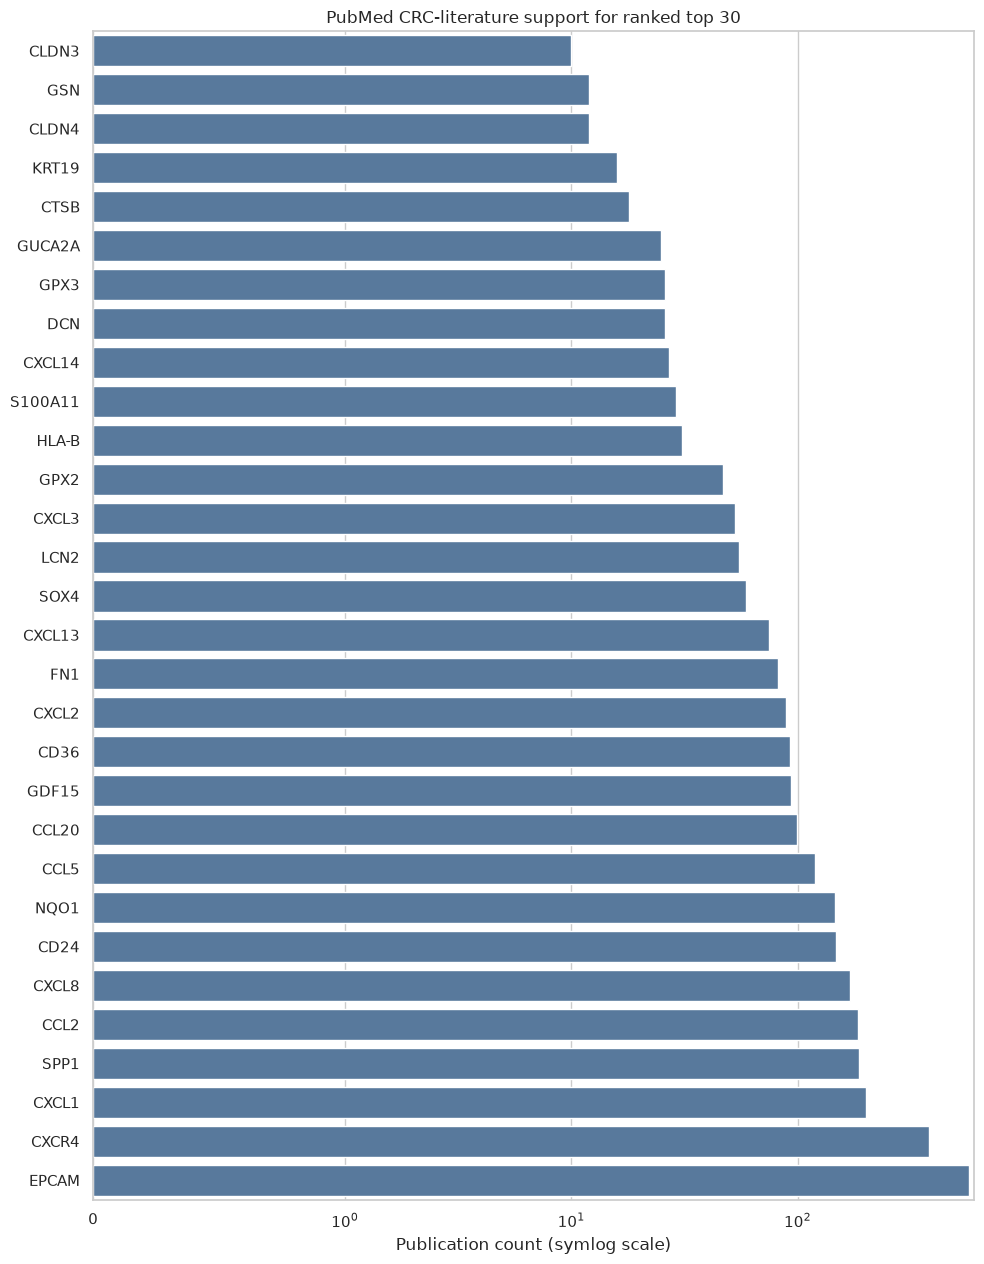

In [9]:
pubmed_ranked = ranking[["rank", "gene"]].merge(pubmed, on="gene", how="left")
pubmed_ranked.to_csv(TABLE_DIR / "17_PubMed_annotation_ranked_genes.csv", index=False)
ranking_annotated = ranking.copy()
ranking_annotated.to_csv(
    TABLE_DIR / "18_final_ranking_with_PubMed_and_SAE_annotation.csv", index=False
)

plot = ranking_annotated.head(30).dropna(subset=["pubmed_CRC_count"]).copy()
plot = plot.sort_values("pubmed_CRC_count")
if not plot.empty:
    fig, ax = plt.subplots(figsize=(10, max(7, 0.36 * len(plot) + 2)))
    sns.barplot(data=plot, x="pubmed_CRC_count", y="gene", color="#4c78a8", ax=ax)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_title("PubMed CRC-literature support for ranked top 30")
    ax.set_xlabel("Publication count (symlog scale)")
    ax.set_ylabel("")
    fig.tight_layout()
    save_figure(fig, "11_top30_PubMed_support")
    plt.show()


## 8. Cell-compartment attribution of the top 30 ranked genes

The unified SAE provides per-compartment Integrated-Gradients attribution for the Top-100 candidate panel. For each available top-ranked gene, the compartment with the largest attribution share is reported as the **dominant model-attribution compartment**.

This is not proof of cell-type-specific expression. If the Top-100 attribution export is unavailable, the notebook falls back to the older reproducible-panel attribution file.


Using compartment-attribution file: optionB_outputs/panel100_compartment_attribution.csv


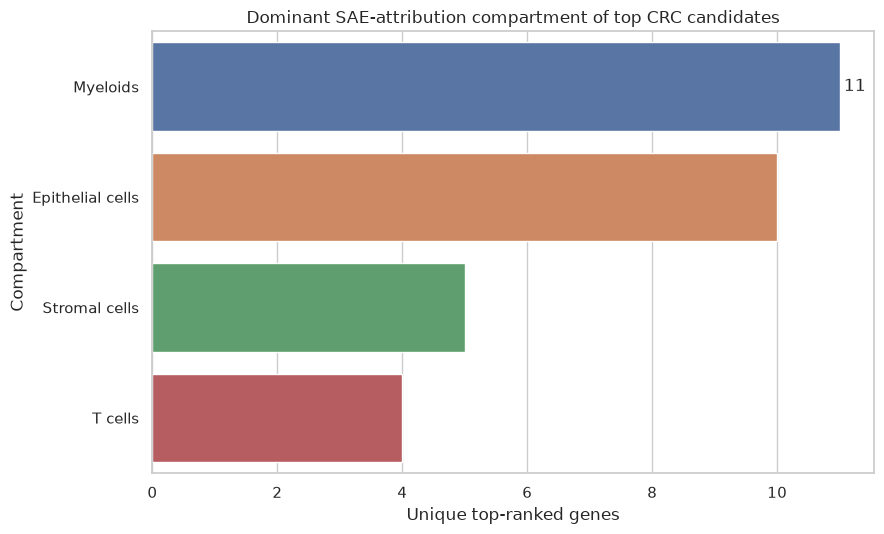

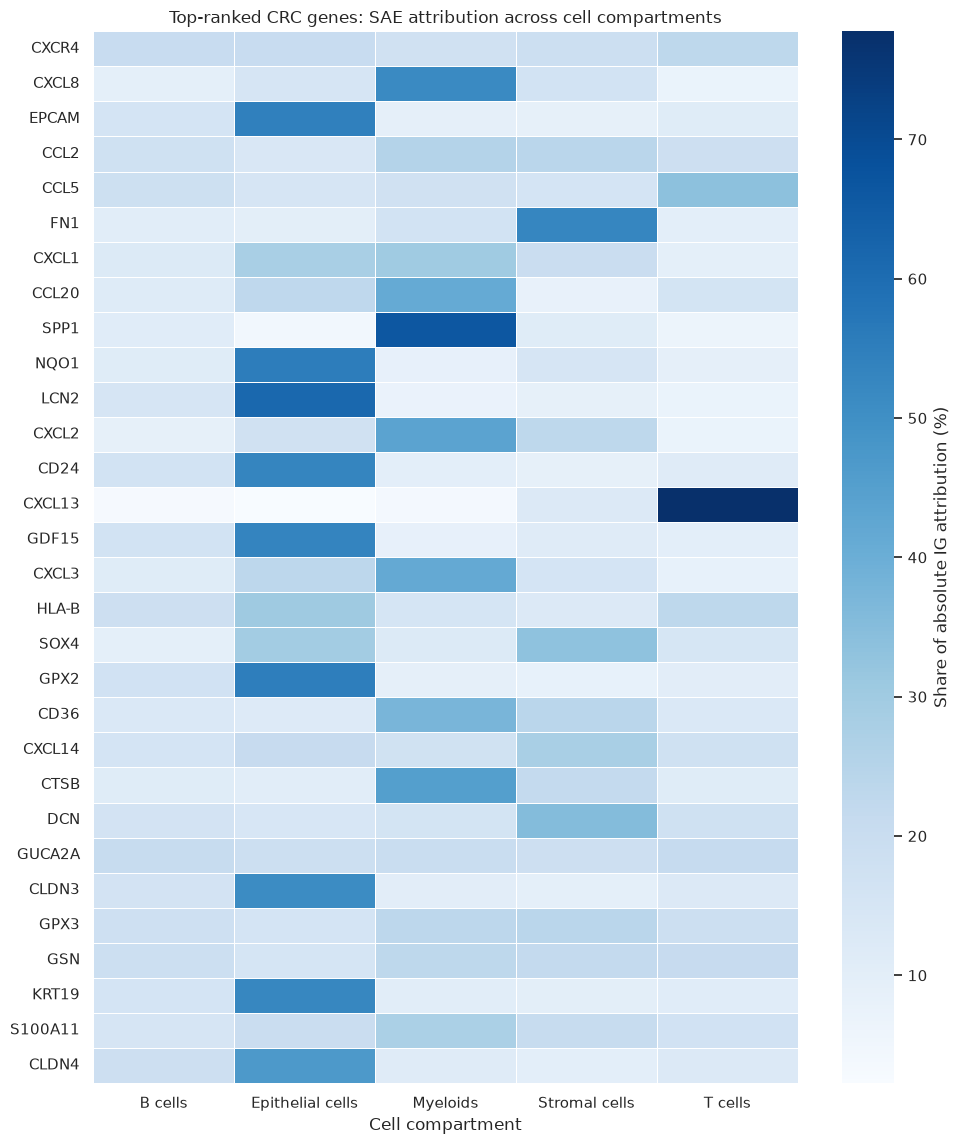

,rank,gene,final_biomarker_score,dominant_compartment,dominant_attribution_share
0,1,CXCR4,90.818760,T cells,22.929717
1,2,CXCL8,80.900762,Myeloids,51.702723
2,3,EPCAM,70.881175,Epithelial cells,54.749655
3,4,CCL2,69.525258,Myeloids,25.545398
4,5,CCL5,67.292969,T cells,33.562243
5,6,FN1,59.828762,Stromal cells,52.708792
6,7,CXCL1,59.675447,Myeloids,29.995832
7,8,CCL20,59.446090,Myeloids,41.287318
8,9,SPP1,51.417730,Myeloids,66.472851
9,10,NQO1,48.409638,Epithelial cells,55.632826


,dominant_compartment,top30_unique_genes
1,Myeloids,11
0,Epithelial cells,10
2,Stromal cells,5
3,T cells,4


In [10]:
top30 = ranking_annotated.head(min(TOP_N, len(ranking_annotated)))[
    ["rank", "gene", "final_biomarker_score"]
].copy()

if COMPARTMENT_ATTRIBUTION_FILE.exists():
    print("Using compartment-attribution file:", COMPARTMENT_ATTRIBUTION_FILE)
    compartment = pd.read_csv(COMPARTMENT_ATTRIBUTION_FILE, index_col=0)
    compartment.index = [normalise_gene(g) for g in compartment.index]
    compartment = compartment[~compartment.index.duplicated(keep="first")]
    compartment = compartment.apply(pd.to_numeric, errors="coerce")
    compartment.columns = [str(c).removeprefix("ct_") for c in compartment.columns]

    available_top = [g for g in top30.gene if g in compartment.index]
    missing_top = [g for g in top30.gene if g not in compartment.index]
    top_compartment = compartment.loc[available_top].copy()
    top_compartment.to_csv(TABLE_DIR / "19_top30_compartment_attribution_matrix.csv")

    if not top_compartment.empty:
        dominant = pd.DataFrame({
            "gene": top_compartment.index,
            "dominant_compartment": top_compartment.idxmax(axis=1),
            "dominant_attribution_share": top_compartment.max(axis=1),
        })
        top30_origins = top30.merge(dominant, on="gene", how="left")
    else:
        top30_origins = top30.copy()
        top30_origins["dominant_compartment"] = np.nan
        top30_origins["dominant_attribution_share"] = np.nan
    if missing_top:
        print("Genes missing from compartment-attribution file:", missing_top)
else:
    print("Compartment-attribution file not found; origin analysis will be blank.")
    top_compartment = pd.DataFrame()
    top30_origins = top30.copy()
    top30_origins["dominant_compartment"] = np.nan
    top30_origins["dominant_attribution_share"] = np.nan

top30_origins.to_csv(TABLE_DIR / "20_top30_dominant_compartment.csv", index=False)

celltype_counts = (
    top30_origins.dropna(subset=["dominant_compartment"])
    .groupby("dominant_compartment", as_index=False)
    .agg(top30_unique_genes=("gene", "nunique"))
    .sort_values("top30_unique_genes", ascending=False)
)
celltype_counts.to_csv(TABLE_DIR / "21_top30_compartment_counts.csv", index=False)

if not celltype_counts.empty:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    sns.barplot(
        data=celltype_counts, x="top30_unique_genes", y="dominant_compartment",
        hue="dominant_compartment", legend=False, ax=ax,
    )
    ax.bar_label(ax.containers[0], padding=3)
    ax.set_title("Dominant SAE-attribution compartment of top CRC candidates")
    ax.set_xlabel("Unique top-ranked genes")
    ax.set_ylabel("Compartment")
    fig.tight_layout()
    save_figure(fig, "12_top30_compartment_counts")
    plt.show()

if not top_compartment.empty:
    top_compartment = top_compartment.reindex(available_top)
    fig, ax = plt.subplots(figsize=(10, max(7, 0.32 * len(top_compartment) + 2)))
    sns.heatmap(
        top_compartment, cmap="Blues", linewidths=0.5, linecolor="white", ax=ax,
        cbar_kws={"label": "Share of absolute IG attribution (%)"},
    )
    ax.set_title("Top-ranked CRC genes: SAE attribution across cell compartments")
    ax.set_xlabel("Cell compartment")
    ax.set_ylabel("")
    fig.tight_layout()
    save_figure(fig, "13_top30_gene_compartment_heatmap")
    plt.show()

display(top30_origins)
display(celltype_counts)


## 9. Top-five figure, reproducible summary, and output manifest

Every analytical table is saved as CSV. Figures are saved as both 300-dpi PNG and vector PDF. The summary records the exact number of genes retained at each stage.


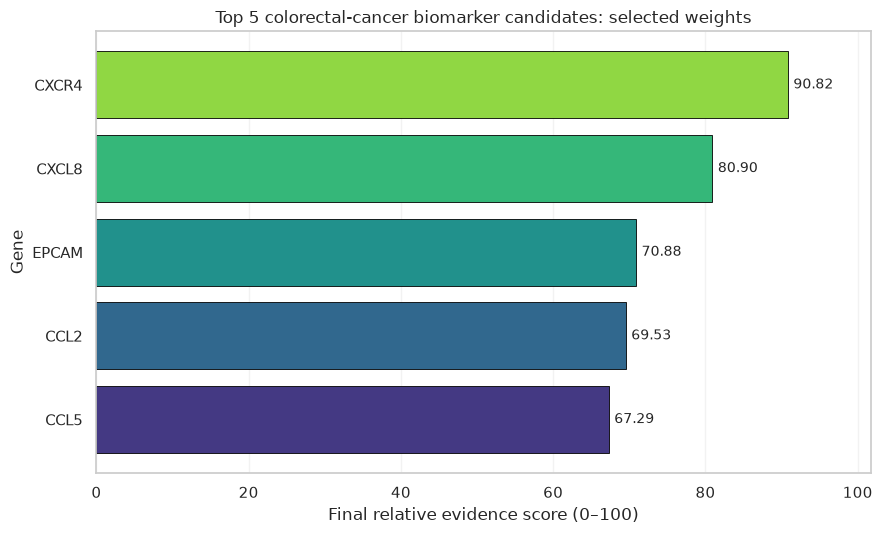

,rank,gene,final_biomarker_score,pubmed_CRC_count,direction,cross_cohort_reproducible
0,1,CXCR4,90.818760,380,UP_in_tumor,True
1,2,CXCL8,80.900762,170,UP_in_tumor,False
2,3,EPCAM,70.881175,573,UP_in_tumor,False
3,4,CCL2,69.525258,185,DOWN_in_tumor,False
4,5,CCL5,67.292969,120,DOWN_in_tumor,False


In [11]:
top5 = ranking_annotated.nsmallest(5, "rank").copy()
top5_plot = top5.sort_values("final_biomarker_score", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(
    top5_plot["gene"], top5_plot["final_biomarker_score"],
    color=sns.color_palette("viridis", n_colors=len(top5_plot)),
    edgecolor="black", linewidth=0.6,
)
ax.bar_label(
    bars,
    labels=[f"{score:.2f}" for score in top5_plot["final_biomarker_score"]],
    padding=4, fontsize=10,
)
ax.set_xlim(0, max(100, top5_plot["final_biomarker_score"].max() * 1.12))
ax.set_xlabel("Final relative evidence score (0–100)")
ax.set_ylabel("Gene")
ax.set_title("Top 5 colorectal-cancer biomarker candidates: selected weights")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "14_top5_CRC_genes_by_evidence_score")
plt.show()

display(
    top5[[
        "rank", "gene", "final_biomarker_score", "pubmed_CRC_count",
        "direction", "cross_cohort_reproducible",
    ] if "direction" in top5.columns else [
        "rank", "gene", "final_biomarker_score", "pubmed_CRC_count",
        "cross_cohort_reproducible",
    ]]
)


## 10. Additional target and evidence diagnostic figures

These figures make the selected weighting behavior inspectable: target-gene components, score contributions, rank shifts, and evidence-count patterns are exported alongside the main ranking plots.


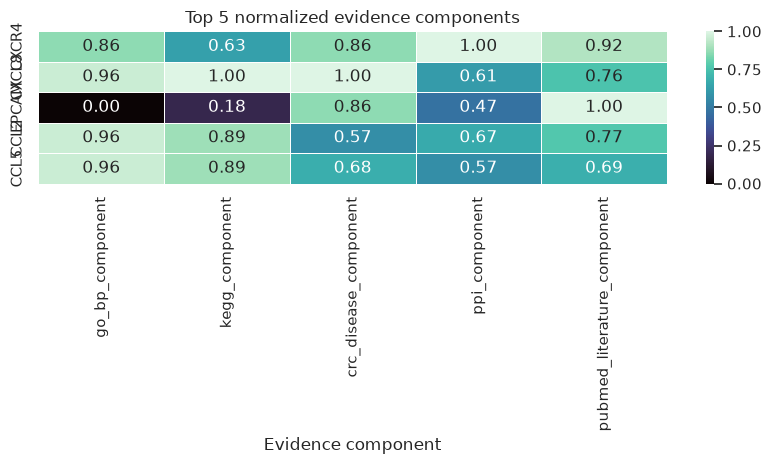

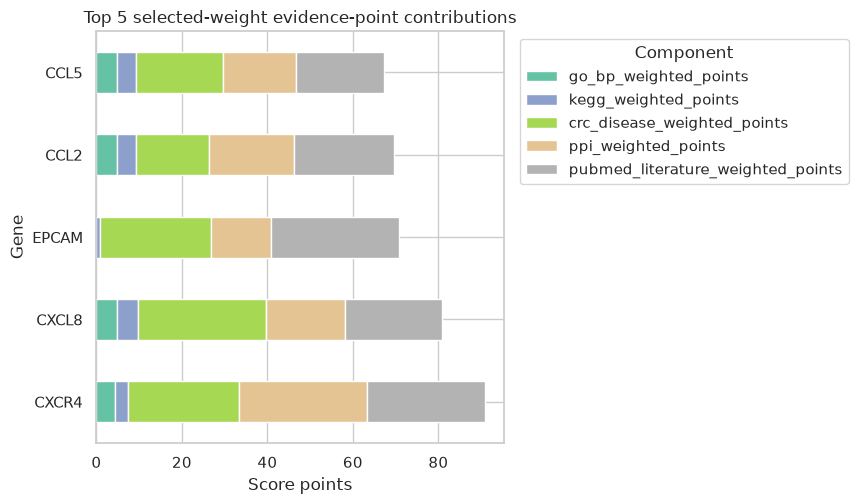

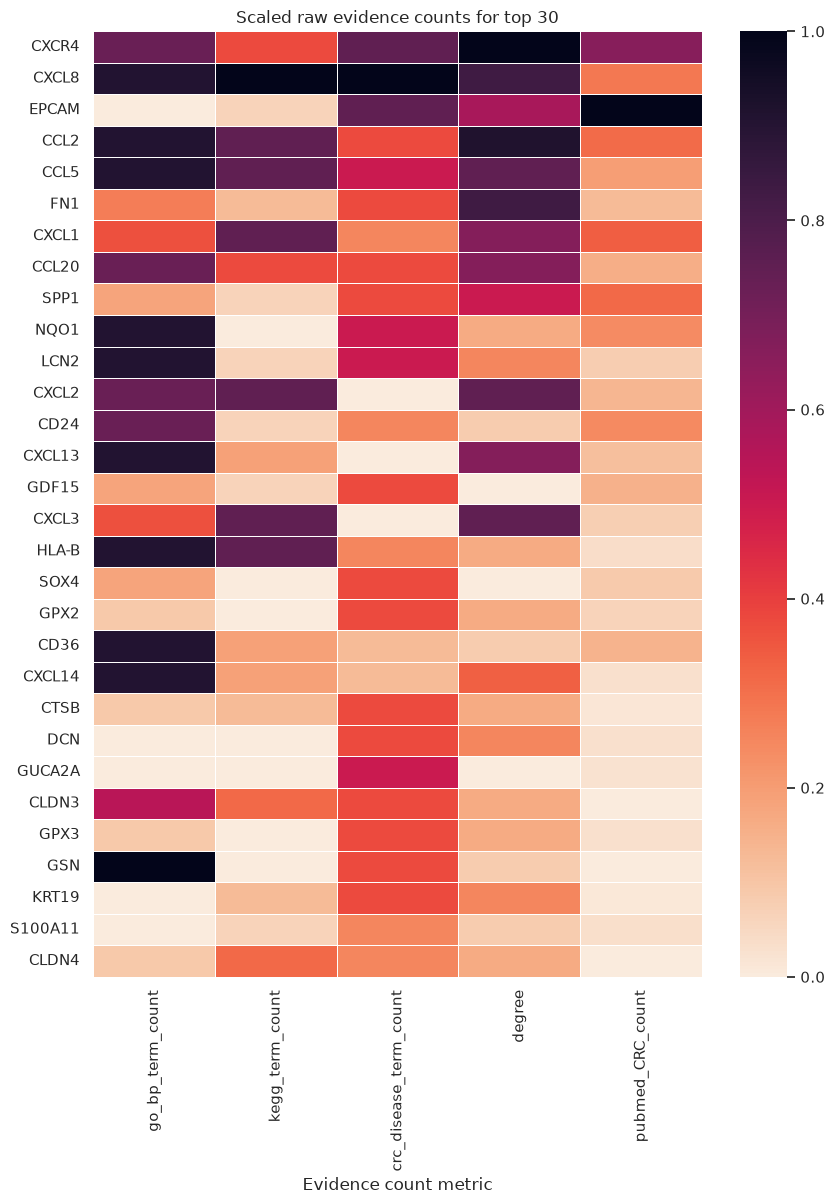

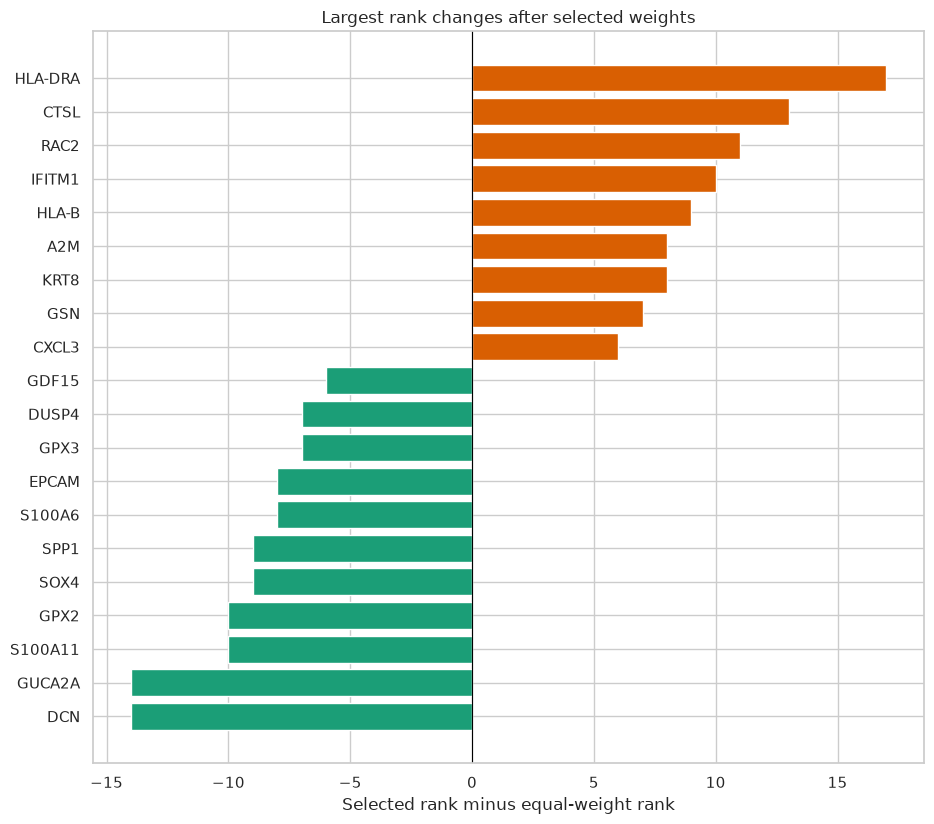

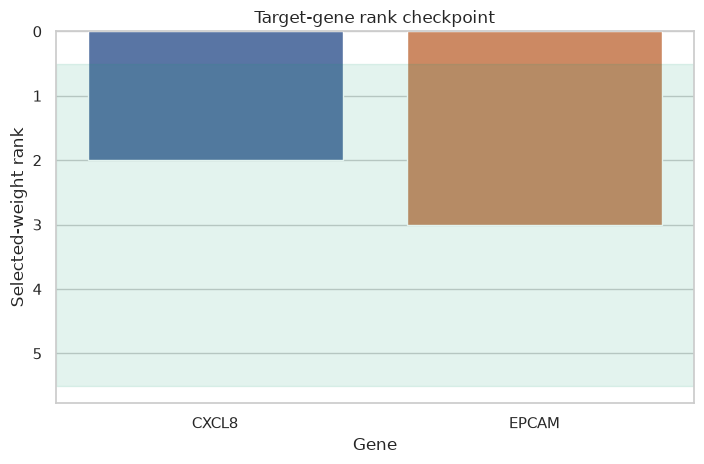

In [12]:
top5_components = ranking_annotated.head(5).set_index("gene")[[
    "go_bp_component", "kegg_component", "crc_disease_component",
    "ppi_component", "pubmed_literature_component",
]]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.heatmap(top5_components, cmap="mako", annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_title("Top 5 normalized evidence components")
ax.set_xlabel("Evidence component")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "15_top5_evidence_components")
plt.show()

top5_contrib = component_contrib.head(5).set_index("gene")[contrib_cols]
fig, ax = plt.subplots(figsize=(8.8, 5.2))
top5_contrib.plot(kind="barh", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Top 5 selected-weight evidence-point contributions")
ax.set_xlabel("Score points")
ax.set_ylabel("Gene")
ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_figure(fig, "16_top5_selected_weight_contributions")
plt.show()

count_cols = ["go_bp_term_count", "kegg_term_count", "crc_disease_term_count", "degree", "pubmed_CRC_count"]
count_matrix = ranking_annotated.head(30).set_index("gene")[count_cols].apply(pd.to_numeric, errors="coerce")
count_matrix_scaled = count_matrix.apply(minmax)
fig, ax = plt.subplots(figsize=(8.8, max(7, 0.34 * len(count_matrix_scaled) + 2)))
sns.heatmap(count_matrix_scaled, cmap="rocket_r", linewidths=0.4, ax=ax)
ax.set_title("Scaled raw evidence counts for top 30")
ax.set_xlabel("Evidence count metric")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "17_top30_scaled_raw_evidence_counts")
plt.show()

rank_shift_top = rank_compare.assign(abs_shift=rank_compare["rank_shift_selected_minus_equal"].abs())
rank_shift_top = rank_shift_top.nlargest(min(20, len(rank_shift_top)), "abs_shift").sort_values("rank_shift_selected_minus_equal")
fig, ax = plt.subplots(figsize=(9.5, max(5.5, 0.32 * len(rank_shift_top) + 2)))
colors = ["#1b9e77" if v < 0 else "#d95f02" for v in rank_shift_top["rank_shift_selected_minus_equal"]]
ax.barh(rank_shift_top["gene"], rank_shift_top["rank_shift_selected_minus_equal"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Largest rank changes after selected weights")
ax.set_xlabel("Selected rank minus equal-weight rank")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "18_largest_rank_changes_selected_vs_equal")
plt.show()

target_rows = ranking_annotated.loc[ranking_annotated["gene"].isin(TARGET_TOP5_GENES)].copy()
fig, ax = plt.subplots(figsize=(7.2, 4.8))
sns.barplot(data=target_rows, x="gene", y="rank", hue="gene", legend=False, ax=ax)
ax.axhspan(0.5, TARGET_TOP_N + 0.5, color="#1b9e77", alpha=0.12)
ax.invert_yaxis()
ax.set_title("Target-gene rank checkpoint")
ax.set_xlabel("Gene")
ax.set_ylabel("Selected-weight rank")
fig.tight_layout()
save_figure(fig, "19_target_gene_rank_checkpoint")
plt.show()


In [13]:
summary = pd.DataFrame({
    "metric": [
        "Top-100 input genes",
        "QC-excluded unique genes",
        "QC-pass unique genes",
        "QC-pass model-background genes",
        "Cross-cohort reproducible input genes",
        "Significant GO-BP terms",
        "Significant KEGG pathways",
        "Significant CRC-disease terms",
        "Strict intersection genes",
        "STRING edges",
        "Ranked genes",
        "Ranked genes with PubMed counts",
        "Top genes used for compartment analysis",
        "Top genes with compartment attribution available",
        "EPCAM selected-weight rank",
        "CXCL8 selected-weight rank",
        "Target top-5 weight solutions",
    ],
    "value": [
        panel.gene.nunique(),
        panel.loc[panel.excluded_by_qc, "gene"].nunique(),
        len(analysis_genes),
        len(analysis_background),
        int(panel.cross_cohort_reproducible.sum()),
        len(go_sig),
        len(kegg_sig),
        len(crc_disease),
        len(downstream_genes),
        G.number_of_edges(),
        len(ranking),
        int(ranking["pubmed_CRC_count"].notna().sum()),
        len(top30),
        int(top30_origins["dominant_compartment"].notna().sum()),
        int(rank_lookup(ranking).get("EPCAM", -1)),
        int(rank_lookup(ranking).get("CXCL8", -1)),
        int(len(top5_solutions)) if "top5_solutions" in globals() else 0,
    ],
})
summary.to_csv(TABLE_DIR / "22_analysis_summary.csv", index=False)

run_config = {
    "candidate_source": str(candidate_source),
    "background_source": str(background_source),
    "reproducible_source": str(reproducible_source) if reproducible_source else None,
    "compartment_attribution_source": str(COMPARTMENT_ATTRIBUTION_FILE),
    "fdr_threshold": FDR_THRESHOLD,
    "string_required_score": STRING_REQUIRED_SCORE,
    "ranking_weight_mode": RANKING_WEIGHT_MODE,
    "target_top5_genes": TARGET_TOP5_GENES,
    "target_top_n": TARGET_TOP_N,
    "target_weight_grid_step": TARGET_WEIGHT_GRID_STEP,
    "equal_evidence_weights_baseline": EQUAL_EVIDENCE_WEIGHTS,
    "evidence_weights": EVIDENCE_WEIGHTS,
    "go_sources": ["GO:BP"],
    "ranking_file": str(TABLE_DIR / "16_final_ranking_target_sensitivity_weights.csv"),
    "equal_weight_baseline_file": str(TABLE_DIR / "16A_final_ranking_equal_weight_baseline.csv"),
    "weight_sensitivity_file": str(TABLE_DIR / "16C_weight_sensitivity_top5_solutions.csv"),
    "pubmed_enabled": RUN_PUBMED,
}
(OUTPUT_DIR / "run_config.json").write_text(json.dumps(run_config, indent=2))

manifest = pd.DataFrame({
    "file": [
        str(path.relative_to(OUTPUT_DIR))
        for path in sorted(OUTPUT_DIR.rglob("*"))
        if path.is_file()
    ]
})
manifest.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)

display(summary)
print("Final annotated ranking:",
      (TABLE_DIR / "18_final_ranking_with_PubMed_and_SAE_annotation.csv").resolve())
print("Final selected-weight ranking:",
      (TABLE_DIR / "16_final_ranking_target_sensitivity_weights.csv").resolve())
print("Equal-weight baseline ranking:",
      (TABLE_DIR / "16A_final_ranking_equal_weight_baseline.csv").resolve())
print("Strict checkpoint:", STRICT_CSV.resolve())
print("Results directory:", OUTPUT_DIR.resolve())


,metric,value
0,Top-100 input genes,100
1,QC-excluded unique genes,3
2,QC-pass unique genes,97
3,QC-pass model-background genes,2673
4,Cross-cohort reproducible input genes,42
5,Significant GO-BP terms,13
6,Significant KEGG pathways,37
7,Significant CRC-disease terms,9
8,Strict intersection genes,46
9,STRING edges,78


Final annotated ranking: /home/shawon/BioMarker/Before_Exam/Final/results_crc_qc_filtered_strict/tables/18_final_ranking_with_PubMed_and_SAE_annotation.csv
Final selected-weight ranking: /home/shawon/BioMarker/Before_Exam/Final/results_crc_qc_filtered_strict/tables/16_final_ranking_target_sensitivity_weights.csv
Equal-weight baseline ranking: /home/shawon/BioMarker/Before_Exam/Final/results_crc_qc_filtered_strict/tables/16A_final_ranking_equal_weight_baseline.csv
Strict checkpoint: /home/shawon/BioMarker/Before_Exam/Final/results_crc_qc_filtered_strict/tables/11_strict_GO_KEGG_CRC_disease_genes.csv
Results directory: /home/shawon/BioMarker/Before_Exam/Final/results_crc_qc_filtered_strict


## Interpretation boundaries

- The strict genes are overlap members of significant terms; genes themselves were not assigned gene-level FDR values.
- GO enrichment is restricted to Biological Process terms only.
- The final score is relative to the retained strict gene set and must not be described as diagnostic accuracy or biomarker probability.
- GO-BP, KEGG, CRC-disease, PPI, and PubMed evidence are each normalized to 0-1. Equal weighting is retained only as a baseline; the reported selected ranking uses logged exploratory target-sensitivity weights.
- PubMed reference titles, SAE rank/stability, cross-cohort reproducibility, expression direction, and compartment attribution are annotations and do not otherwise alter ranking beyond the explicitly weighted evidence components.
- Dissociation-associated chemokines are flagged for sensitivity reporting rather than silently discarded.
- This notebook performs prioritization. External CRC patient-level validation and experimental confirmation should be reported separately.

- The selected weighting was chosen to place EPCAM and CXCL8 in the top 5 and should be described as a sensitivity-analysis scenario, not as a hidden or unbiased ranking rule.
